In [73]:

# 1. Required packages installation

!pip install pandas numpy matplotlib seaborn plotly scipy statsmodels scikit-learn prophet textblob nltk wordcloud -q
!python -m textblob.download_corpora -q

# libraries importation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

# visualizations style definition
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✓ Packages installed and configured successfully!")

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
Finished.
✓ Packages installed and configured successfully!


In [74]:
# 2. CSV files Loading and concatenation

import glob
import os

# Chemin vers le dossier contenant les fichiers (modifiez selon votre cas)
path = '/content/sample_data/'

# Lister tous les fichiers CSV correspondant au pattern
files = glob.glob(os.path.join(path, 'wasteCollectedData_*.csv'))
print(f"Nombre de fichiers trouvés : {len(files)}")

# Lire et concaténer
df_list = []
for f in files:
    df_temp = pd.read_csv(f, on_bad_lines='skip', engine='python')
    df_temp['source_file'] = os.path.basename(f)  # optionnel
    df_list.append(df_temp)

df = pd.concat(df_list, ignore_index=True)

print(f"Dimensions totales : {df.shape}")
print("\nColonnes :", df.columns.tolist())
print("\nAperçu :")
df.head(10)

Nombre de fichiers trouvés : 14
Dimensions totales : (883764, 27)

Colonnes : ['timestamp', 'name', 'neighborhood', 'type', 'municipality', 'battery', 'behaviorScore', 'collectionRecommended', 'collectionUrgency', 'dailyOpenings', 'depositEfficiency', 'deposits', 'distance', 'fillPercentage', 'forecastDate', 'lastCalculationTime', 'lastCollectionDate', 'markerColor', 'nextCollectionDate', 'nightlyOpenings', 'position', 'totalWeightKg', 'wasteVolumeLiters', 'wasteWeightKg', 'source_file', 'firstOpeningTime', 'lastOpeningTime']

Aperçu :


,timestamp,name,neighborhood,type,municipality,battery,behaviorScore,collectionRecommended,collectionUrgency,dailyOpenings,...,markerColor,nextCollectionDate,nightlyOpenings,position,totalWeightKg,wasteVolumeLiters,wasteWeightKg,source_file,firstOpeningTime,lastOpeningTime
0,2026-01-24 22:30:24.012,sensor1-24e124713c245522,lumumba,Peri-urban,bagira,NaN,NaN,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wasteCollectedData_15.csv,NaN,NaN
1,2026-01-24 22:30:24.020,sensor1-24e124713c245522,lumumba,Peri-urban,bagira,NaN,NaN,NaN,"""LOW""",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wasteCollectedData_15.csv,NaN,NaN
2,2026-01-24 22:30:24.028,sensor1-24e124713c245522,lumumba,Peri-urban,bagira,NaN,NaN,NaN,NaN,NaN,...,NaN,1.763297e+12,NaN,NaN,NaN,NaN,NaN,wasteCollectedData_15.csv,NaN,NaN
3,2026-01-24 22:30:24.035,sensor1-24e124713c245522,lumumba,Peri-urban,bagira,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wasteCollectedData_15.csv,NaN,NaN
4,2026-01-24 22:30:25.200,sensor1-24e124713c245522,lumumba,Peri-urban,bagira,81.0,"72,7390180878553",NaN,NaN,0.0,...,NaN,NaN,0.0,NaN,"13,5004258555133","34,8","6,96",wasteCollectedData_15.csv,NaN,NaN
5,2026-01-24 22:30:25.206,sensor1-24e124713c245522,lumumba,Peri-urban,bagira,81.0,"72,7390180878553",NaN,NaN,0.0,...,NaN,NaN,0.0,NaN,"5,48","34,8","6,96",wasteCollectedData_15.csv,NaN,NaN
6,2026-01-24 22:30:25.212,sensor1-24e124713c245522,lumumba,Peri-urban,bagira,81.0,"72,7390180878553",NaN,NaN,0.0,...,NaN,NaN,0.0,NaN,"5,24","34,8","6,96",wasteCollectedData_15.csv,NaN,NaN
7,2026-01-24 22:30:25.217,sensor1-24e124713c245522,lumumba,Peri-urban,bagira,81.0,"72,7390180878553",NaN,NaN,0.0,...,NaN,NaN,0.0,NaN,"11,96","2,4","0,24",wasteCollectedData_15.csv,NaN,NaN
8,2026-01-24 22:30:25.223,sensor1-24e124713c245522,lumumba,Peri-urban,bagira,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wasteCollectedData_15.csv,NaN,NaN
9,2026-01-24 22:30:25.231,sensor1-24e124713c245522,lumumba,Peri-urban,bagira,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wasteCollectedData_15.csv,NaN,NaN


In [75]:
# 3. Data conversion and cleaning

# Convertir timestamp en datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Colonnes numériques suspectes
numeric_cols = ['battery', 'behaviorScore', 'dailyOpenings', 'depositEfficiency',
                'deposits', 'distance', 'fillPercentage', 'totalWeightKg',
                'wasteVolumeLiters', 'wasteWeightKg']

# Remplacer les virgules par des points et convertir en float
def clean_numeric(col):
    if col.dtype == 'object':
        # Remplacer les virgules par des points puis convertir en numérique
        return pd.to_numeric(col.str.replace(',', '.'), errors='coerce')
    return col

for col in numeric_cols:
    if col in df.columns:
        df[col] = clean_numeric(df[col])

# Convertir les dates en millisecondes
date_ms_cols = ['forecastDate', 'lastCalculationTime', 'lastCollectionDate', 'nextCollectionDate']
for col in date_ms_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], unit='ms', errors='coerce')

# Indicateurs de présence
df['has_weight'] = df['wasteWeightKg'].notna()
df['has_recommendation'] = df['collectionRecommended'].notna()
df['has_urgency'] = df['collectionUrgency'].notna()

# Sous-ensemble pour les mesures complètes
df_complete = df[df['wasteWeightKg'].notna()].copy()
print(f"Lignes avec mesures complètes : {df_complete.shape[0]}")

Lignes avec mesures complètes : 262608


In [80]:
# 4. Demographic data addition (population, households)

# Dictionnaire pour associer chaque quartier à sa commune
neighborhood_to_municipality = {
    'nyalukemba': 'Ibanda',
    'panzi': 'Ibanda',
    'ndendere': 'Ibanda',
    'cahi': 'Bagira',
    'nyakavogo': 'Bagira',
    'kasha': 'Bagira',
    'lumumba': 'Bagira',
    'kajangu': 'Kadutu',
    'cimpunda': 'Kadutu',
    'kasali': 'Kadutu',
    'nkafu': 'Kadutu',
    'mosala': 'Kadutu',
    'nyakaliba': 'Kadutu',
    'nyamugo': 'Kadutu'
}

# Dictionnaire pour associer chaque commune à ses nombres de ménages
households_dict = {
    'bagira': 31938,
    'kadutu': 84584,
    'ibanda': 103732
}

# Créer la colonne 'municipality' en fonction du quartier
df['municipality'] = df['neighborhood'].map(neighborhood_to_municipality)

# Vérifier les valeurs uniques (pour déboguer)
print("Municipalités trouvées :", df['municipality'].unique())

# Dictionnaires pour la population et les ménages (2026)
pop_dict = {'Bagira': 207602, 'Kadutu': 549797, 'Ibanda': 674261}
households_dict = {'Bagira': 31939, 'Kadutu': 84584, 'Ibanda': 103732}

# Ajouter les colonnes avec map
df['population_2026'] = df['municipality'].map(pop_dict)
df['households'] = df['municipality'].map(households_dict)

# Vérifier que tout est bien ajouté
print("Colonnes ajoutées :", df[['neighborhood', 'municipality', 'population_2026', 'households']].drop_duplicates())

Municipalités trouvées : ['Bagira' 'Ibanda' nan]
Colonnes ajoutées :        neighborhood municipality  population_2026  households
0           lumumba       Bagira         207602.0     31939.0
125385   nyalukemba       Ibanda         674261.0    103732.0
208249         None          NaN              NaN         NaN
377258       lumumb          NaN              NaN         NaN


=== Statistiques descriptives ===
             battery  behaviorScore  dailyOpenings  depositEfficiency  \
count  155006.000000  260030.000000   47590.000000       47590.000000   
mean       87.755333      72.655021       0.030950          11.344656   
std         3.116692       2.455042       0.016875           8.198575   
min         0.000000      70.000000       0.000000           0.000000   
25%        84.162051      70.895141       0.016129           5.378973   
50%        89.376543      72.739018       0.034483           9.176471   
75%        89.376543      73.761996       0.045455          14.192496   
max       100.000000     100.000000       1.000000         100.000000   

            deposits       distance  fillPercentage  totalWeightKg  \
count  260030.000000  260030.000000    260030.00000  260030.000000   
mean        2.029483     687.290146        19.32521       8.943936   
std         2.613715     140.577140        18.42665       4.157095   
min         0.000000       0

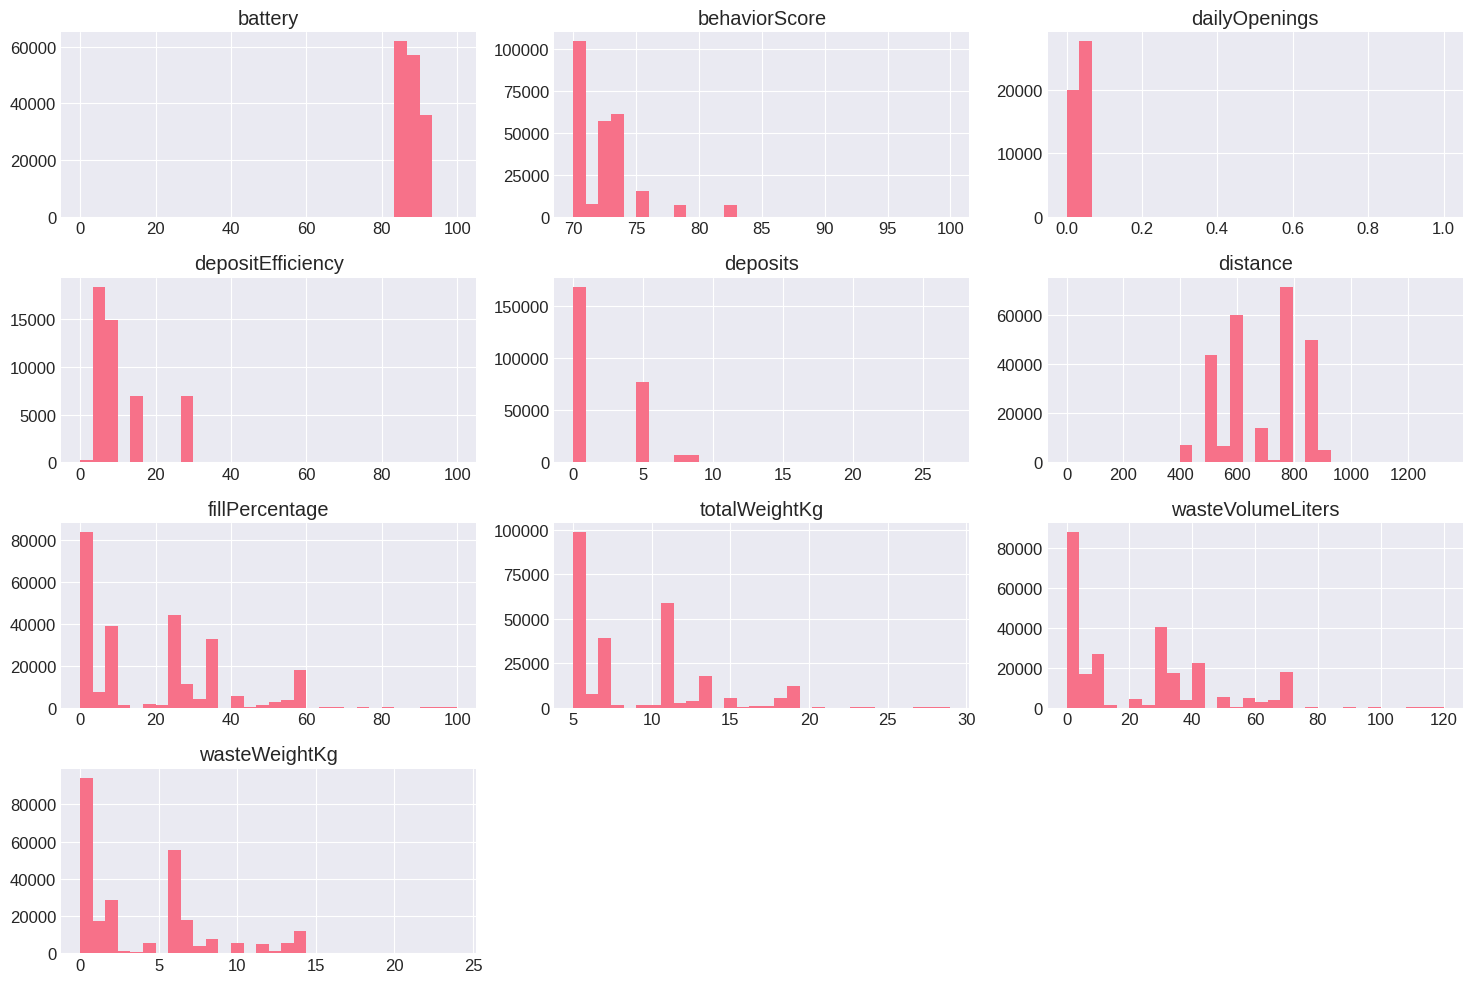

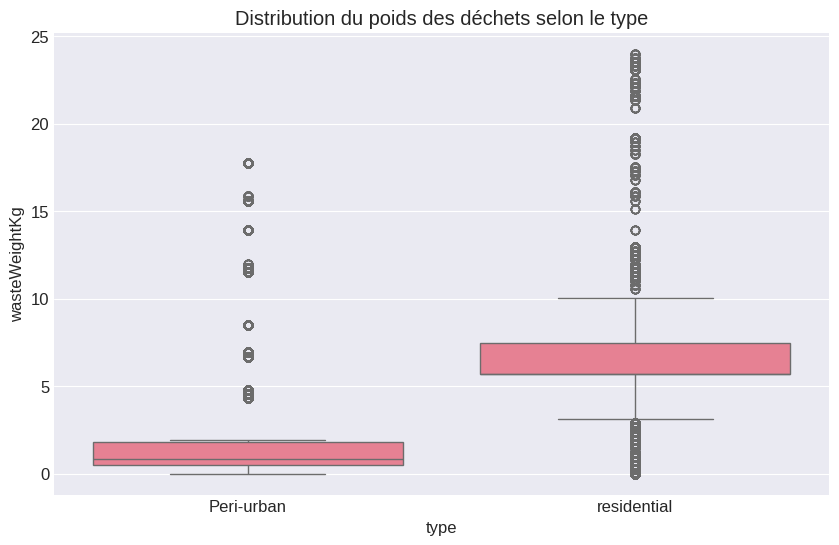

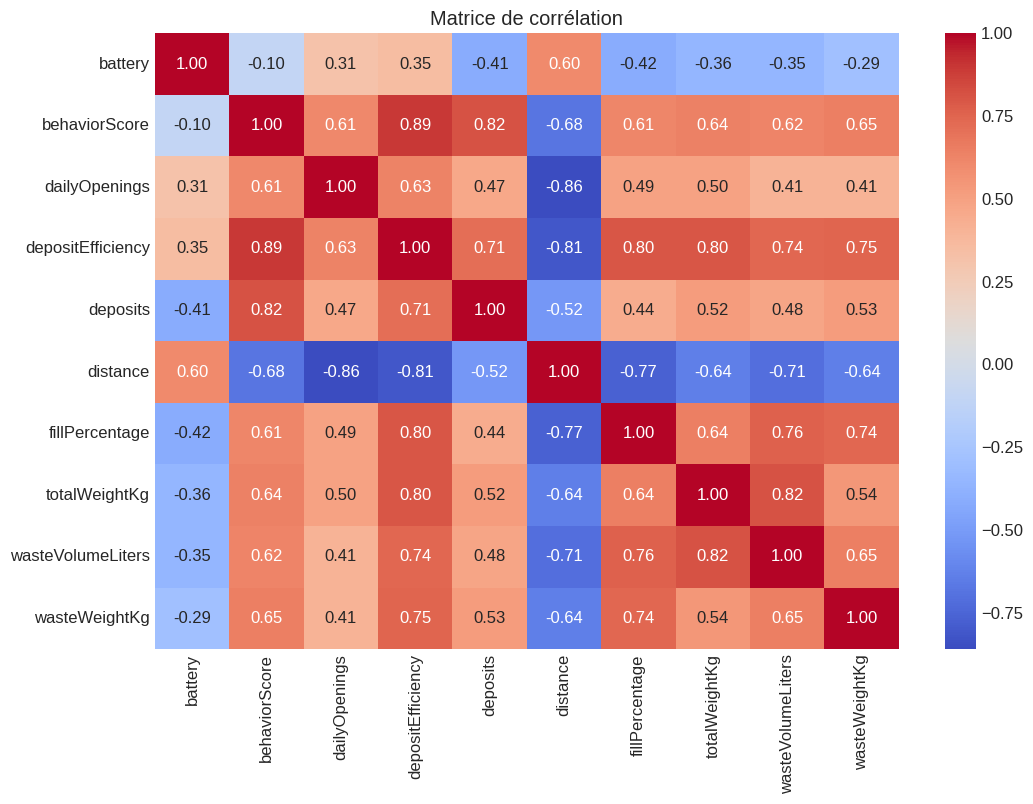

In [58]:
# 5. Descriptive analyses

# Statistiques des variables numériques
print("=== Statistiques descriptives ===")
print(df_complete[numeric_cols].describe())

# Effectifs catégoriels
print("\n=== Effectifs des variables catégorielles ===")
cat_cols = ['name', 'neighborhood', 'type', 'municipality', 'collectionRecommended']
for col in cat_cols:
    if col in df_complete.columns:
        print(f"\n{col} :")
        print(df_complete[col].value_counts(dropna=False))

# Histogrammes
df_complete[numeric_cols].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()

# Boxplots par type
if 'type' in df_complete.columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(x='type', y='wasteWeightKg', data=df_complete)
    plt.title('Distribution du poids des déchets selon le type')
    plt.show()

# Matrice de corrélation
corr = df_complete[numeric_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation')
plt.show()

In [59]:
# 6. Inferential analyses

# Intervalle de confiance pour la moyenne de wasteWeightKg
mean = df_complete['wasteWeightKg'].mean()
sem = stats.sem(df_complete['wasteWeightKg'].dropna())
ci = stats.t.interval(0.95, len(df_complete)-1, loc=mean, scale=sem)
print(f"Moyenne = {mean:.2f}, IC 95% = [{ci[0]:.2f}, {ci[1]:.2f}]")

# Test t entre deux groupes (exemple : comparer deux quartiers)
# Remplacez 'nyalukemba' et 'autre_quartier' par des valeurs réelles
if 'neighborhood' in df_complete.columns:
    group1 = df_complete[df_complete['neighborhood']=='nyalukemba']['wasteWeightKg'].dropna()
    group2 = df_complete[df_complete['neighborhood']=='autre_quartier']['wasteWeightKg'].dropna()
    if len(group1)>0 and len(group2)>0:
        t_stat, p_val = stats.ttest_ind(group1, group2)
        print(f"t-test : t = {t_stat:.3f}, p = {p_val:.4f}")

# ANOVA sur le type
if 'type' in df_complete.columns and len(df_complete['type'].dropna().unique()) >= 2:
    groups = [df_complete[df_complete['type']==cat]['wasteWeightKg'].dropna() for cat in df_complete['type'].unique()]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"ANOVA : F = {f_stat:.3f}, p = {p_val:.4f}")

# ANOVA avec statsmodels (plus détaillée)
if 'type' in df_complete.columns:
    model = ols('wasteWeightKg ~ C(type)', data=df_complete.dropna(subset=['wasteWeightKg', 'type'])).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)

# Test du Chi-carré entre type et collectionRecommended
if 'type' in df.columns and 'collectionRecommended' in df.columns:
    chi_data = df[df['collectionRecommended'].notna() & df['type'].notna()]
    if len(chi_data) > 0:
        table = pd.crosstab(chi_data['type'], chi_data['collectionRecommended'])
        chi2, p, dof, expected = stats.chi2_contingency(table)
        print(f"Chi2 = {chi2:.3f}, p = {p:.4f}")

Moyenne = 4.08, IC 95% = [4.07, 4.10]
ANOVA : F = 38602.063, p = 0.0000
                sum_sq        df             F  PR(>F)
C(type)   5.938303e+05       1.0  38602.062719     0.0
Residual  4.039768e+06  262606.0           NaN     NaN
Chi2 = 1411.976, p = 0.0000


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 23.


=== Régression linéaire ===
RMSE = 2.58
R² = 0.695
Coefficients :
  battery: 0.124
  fillPercentage: 0.021
  dailyOpenings: -19.731
  deposits: 1.215
  distance: 0.008


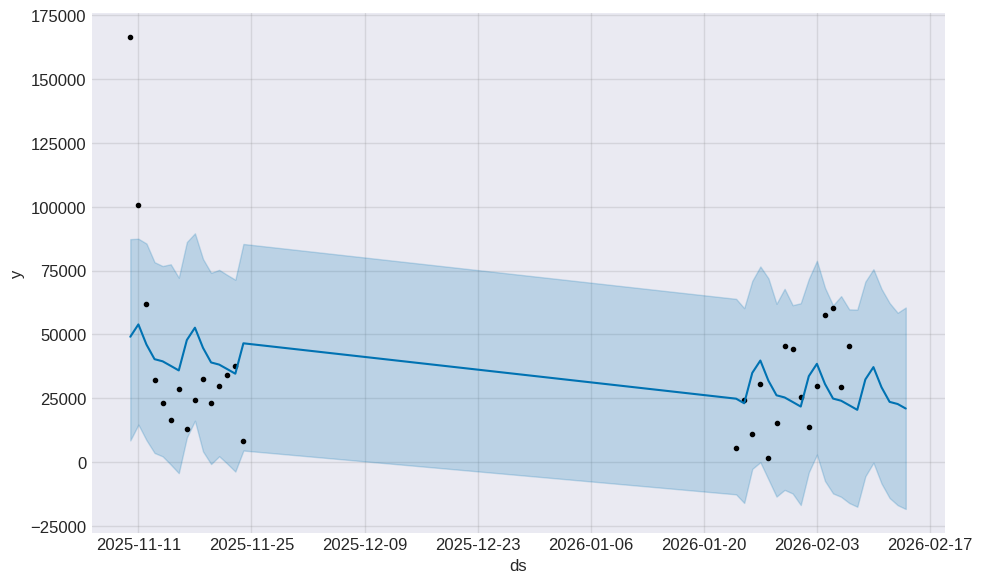

In [60]:
# 7. Predictive models

# Préparation des données pour la régression linéaire
features = ['battery', 'fillPercentage', 'dailyOpenings', 'deposits', 'distance']
target = 'wasteWeightKg'
model_data = df_complete[features + [target]].dropna()
X = model_data[features]
y = model_data[target]

# Division train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Régression linéaire
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
print("=== Régression linéaire ===")
print(f"RMSE = {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R² = {r2_score(y_test, y_pred):.3f}")
print("Coefficients :")
for feat, coef in zip(features, lr.coef_):
    print(f"  {feat}: {coef:.3f}")

# Régression logistique pour collectionRecommended
if 'collectionRecommended' in df_complete.columns:
    log_data = df_complete[df_complete['collectionRecommended'].notna()].copy()
    # Convertir en binaire (True/False)
    log_data['collectionRecommended'] = log_data['collectionRecommended'].astype(str).str.lower().map({'true':1, 'false':0})
    log_X = log_data[features].dropna()
    log_y = log_data.loc[log_X.index, 'collectionRecommended']
    if len(log_y) > 0:
        X_train, X_test, y_train, y_test = train_test_split(log_X, log_y, test_size=0.2, random_state=42)
        from sklearn.linear_model import LogisticRegression
        logreg = LogisticRegression(max_iter=1000)
        logreg.fit(X_train, y_train)
        y_pred = logreg.predict(X_test)
        print("\n=== Régression logistique ===")
        print(classification_report(y_test, y_pred))
        print("Matrice de confusion :")
        print(confusion_matrix(y_test, y_pred))

# Modèle de série temporelle (exemple avec Prophet)
# Agréger par jour
if len(df_complete) > 0:
    ts = df_complete.groupby(df_complete['timestamp'].dt.date)['wasteWeightKg'].sum().reset_index()
    ts.columns = ['ds', 'y']
    ts['ds'] = pd.to_datetime(ts['ds'])
    if len(ts) >= 10:
        from prophet import Prophet
        model = Prophet()
        model.fit(ts)
        future = model.make_future_dataframe(periods=7)
        forecast = model.predict(future)
        model.plot(forecast)
        plt.show()

Clustering terminé.


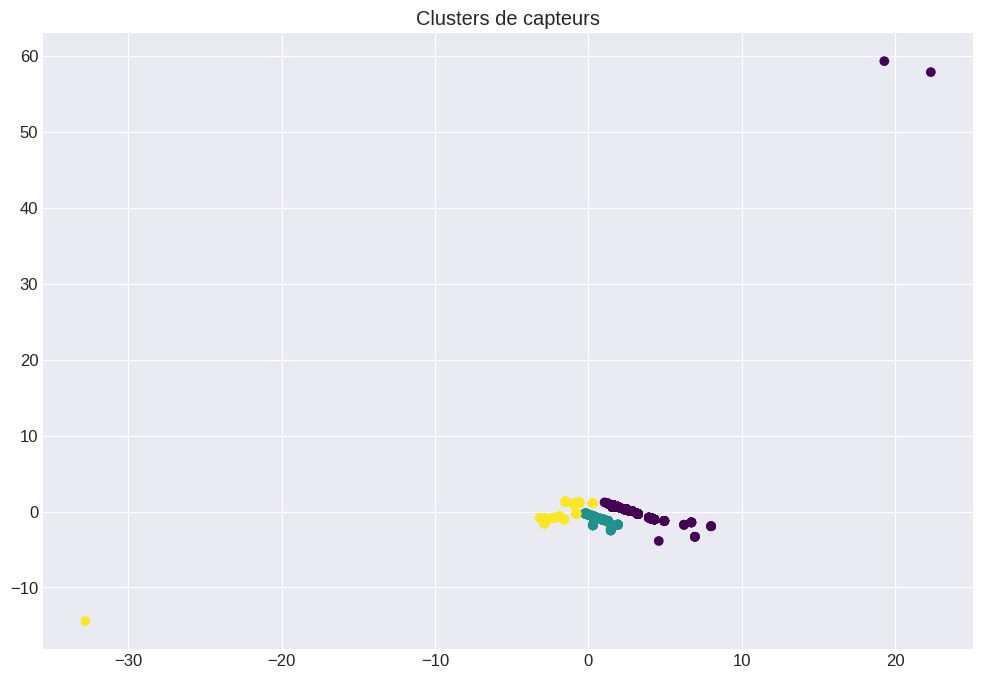

Nombre d'anomalies détectées : 4050


In [61]:
# 8. Sensor clustering and anomaly detection (Isolation Forest)

# Clustering des capteurs
cluster_features = ['battery', 'behaviorScore', 'fillPercentage', 'dailyOpenings']
cluster_data = df_complete[cluster_features].dropna()
if len(cluster_data) > 0:
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    scaled = scaler.fit_transform(cluster_data)
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(scaled)
    df_complete.loc[cluster_data.index, 'cluster'] = clusters
    print("Clustering terminé.")
    # Visualisation avec PCA
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(scaled)
    plt.scatter(pca_result[:,0], pca_result[:,1], c=clusters, cmap='viridis')
    plt.title('Clusters de capteurs')
    plt.show()

# Détection d'anomalies (Isolation Forest)
from sklearn.ensemble import IsolationForest
if len(cluster_data) > 0:
    iso = IsolationForest(contamination=0.1, random_state=42)
    anomaly_pred = iso.fit_predict(scaled)
    df_complete.loc[cluster_data.index, 'anomaly'] = anomaly_pred
    print(f"Nombre d'anomalies détectées : {(anomaly_pred == -1).sum()}")

Percentiles de fillPercentage par quartier :
                    0.25       0.50  0.75
neighborhood                            
lumumba        2.344810   7.518792  29.0
nyalukemba    23.742748  23.742748  35.0


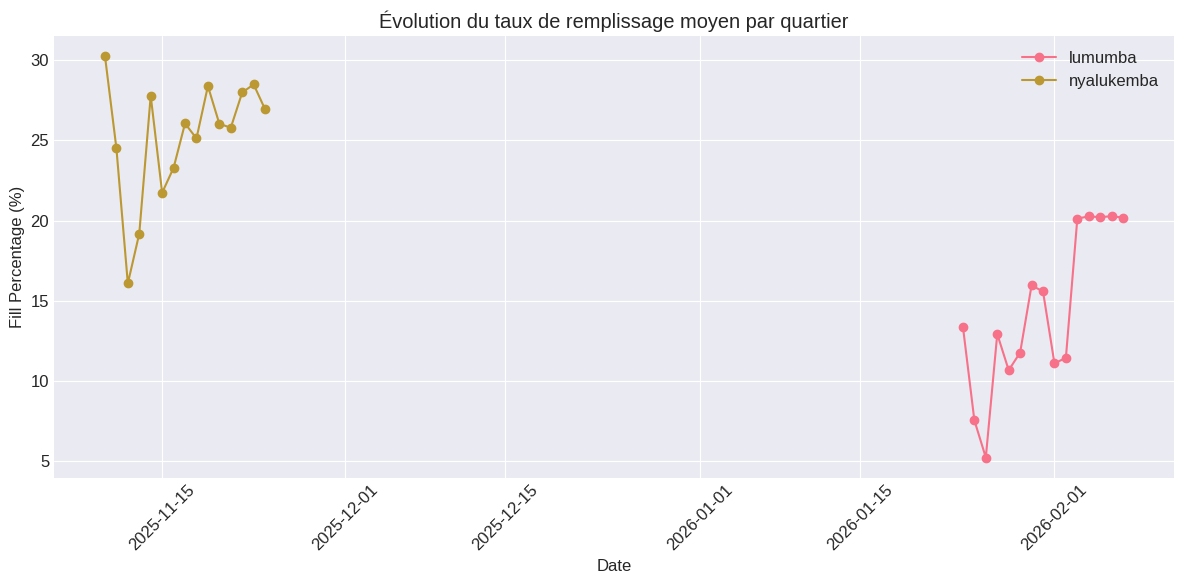

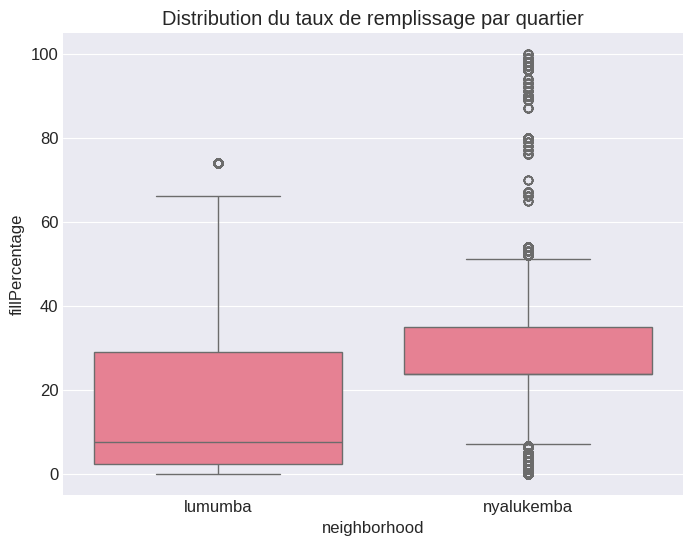


Heures de pointe (fréquence de dépassement du seuil de 80 %) :

lumumba:
   hour  frequency
0     0        0.0
1     1        0.0
2     2        0.0

nyalukemba:
    hour  frequency
32     8   0.021058
34    10   0.019665
33     9   0.019410


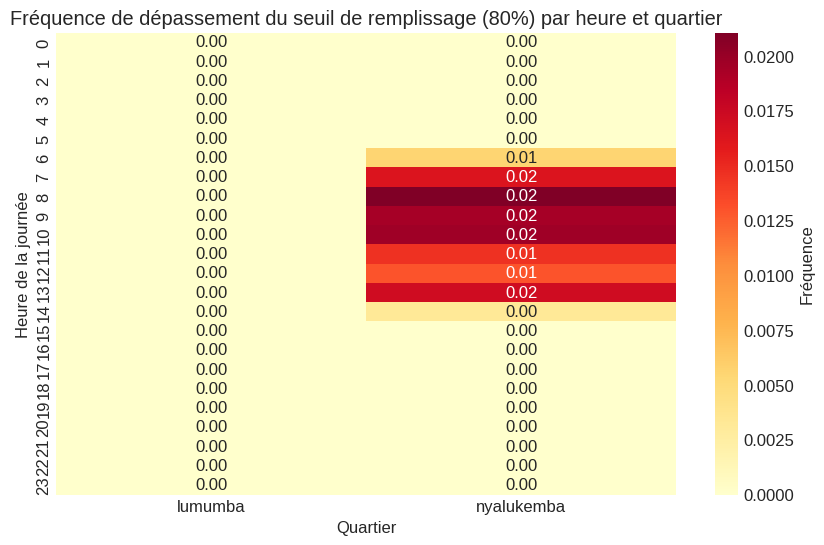


Statistiques de remplissage par quartier :
   neighborhood       mean        std  min    max
0      lumumba  15.217446  19.172899  0.0   74.0
1   nyalukemba  24.935093  15.450941  0.0  100.0


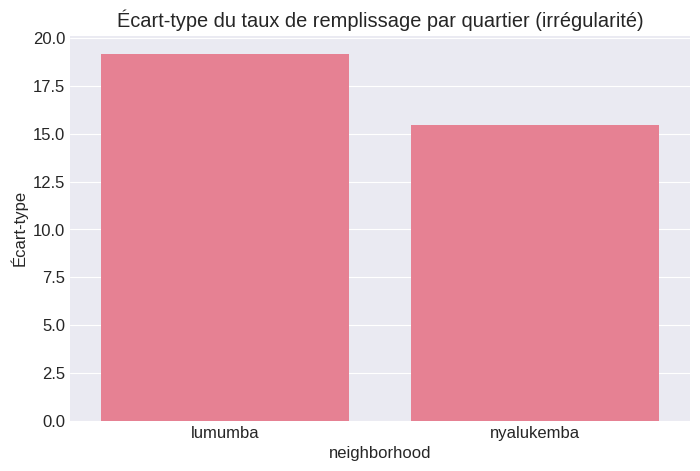


Tendances linéaires (pente par jour) :
                slope   p_value
lumumba     0.897290  0.000294
nyalukemba  0.344208  0.133520


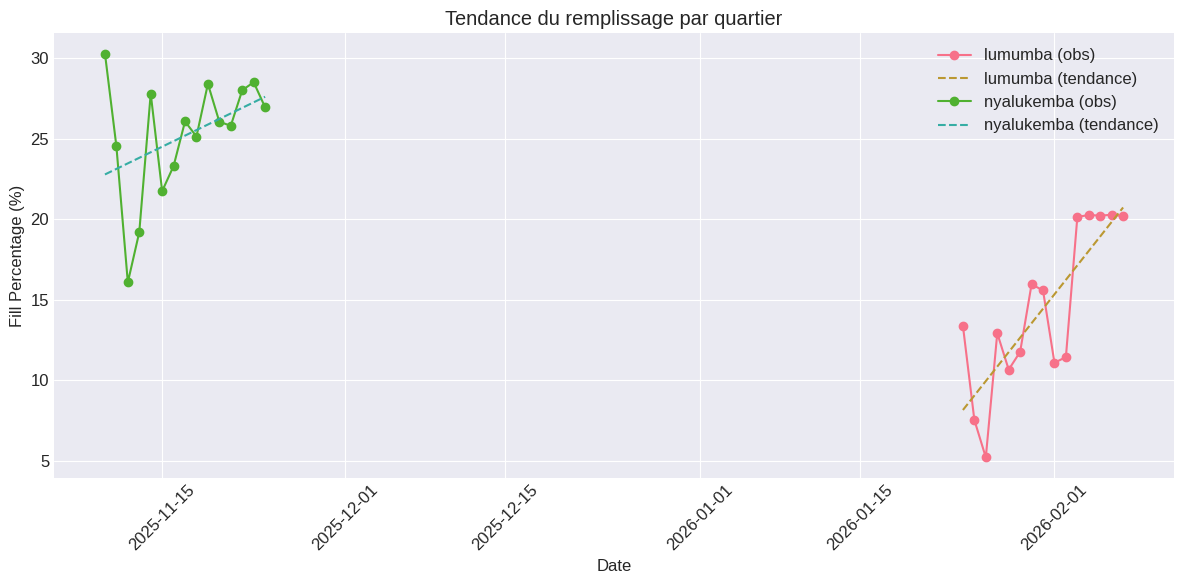

In [62]:
# 9. Waste bin fill percentage in-depth analysis

# -----------------------------------------------------------------------------
# 1. Importations et préparation des données
# -----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

# On suppose que df est le dataframe principal après les étapes de chargement et nettoyage
# (timestamp converti, colonnes numériques corrigées, etc.)

# -----------------------------------------------------------------------------
# 2. Sous-ensemble pour l'analyse de remplissage
# -----------------------------------------------------------------------------
# Filtrer les lignes où fillPercentage est renseigné
df_fill = df[df['fillPercentage'].notna()].copy()
df_fill['timestamp'] = pd.to_datetime(df_fill['timestamp'], errors='coerce')

# Extraire des composantes temporelles pour les agrégations
df_fill['hour'] = df_fill['timestamp'].dt.hour
df_fill['day_of_week'] = df_fill['timestamp'].dt.dayofweek   # lundi=0, dimanche=6
df_fill['date'] = df_fill['timestamp'].dt.date

# -----------------------------------------------------------------------------
# 3. Courbes de remplissage par quartier (moyenne, percentiles)
# -----------------------------------------------------------------------------
# Moyenne journalière par quartier
daily_fill = df_fill.groupby(['neighborhood', 'date'])['fillPercentage'].mean().reset_index()

# Percentiles globaux par quartier
percentiles = df_fill.groupby('neighborhood')['fillPercentage'].quantile([0.25, 0.5, 0.75]).unstack()
print("Percentiles de fillPercentage par quartier :\n", percentiles)

# Tracé des courbes moyennes avec matplotlib
plt.figure(figsize=(12, 6))
for nb in daily_fill['neighborhood'].unique():
    data = daily_fill[daily_fill['neighborhood'] == nb]
    plt.plot(data['date'], data['fillPercentage'], marker='o', linestyle='-', label=nb)
plt.xlabel('Date')
plt.ylabel('Fill Percentage (%)')
plt.title('Évolution du taux de remplissage moyen par quartier')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Tracé interactif avec plotly
fig = px.line(daily_fill, x='date', y='fillPercentage', color='neighborhood',
              title='Évolution du taux de remplissage moyen par quartier')
fig.show()

# Boxplots pour visualiser la distribution par quartier
plt.figure(figsize=(8, 6))
sns.boxplot(x='neighborhood', y='fillPercentage', data=df_fill)
plt.title('Distribution du taux de remplissage par quartier')
plt.show()

# -----------------------------------------------------------------------------
# 4. Heures de pointe de remplissage (identification des moments > seuil, ex. 80%)
# -----------------------------------------------------------------------------
threshold = 80
df_fill['above_threshold'] = df_fill['fillPercentage'] > threshold

# Fréquence de dépassement par quartier et heure
peak_hours = df_fill.groupby(['neighborhood', 'hour'])['above_threshold'].sum().reset_index()
total_measures = df_fill.groupby(['neighborhood', 'hour']).size().reset_index(name='count')
peak_hours = peak_hours.merge(total_measures, on=['neighborhood', 'hour'])
peak_hours['frequency'] = peak_hours['above_threshold'] / peak_hours['count']

# Afficher les 3 heures avec la plus haute fréquence par quartier
print("\nHeures de pointe (fréquence de dépassement du seuil de {} %) :".format(threshold))
for nb in peak_hours['neighborhood'].unique():
    top = peak_hours[peak_hours['neighborhood'] == nb].nlargest(3, 'frequency')
    print(f"\n{nb}:")
    print(top[['hour', 'frequency']])

# Heatmap des fréquences par heure et quartier
pivot = peak_hours.pivot(index='hour', columns='neighborhood', values='frequency')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap='YlOrRd', fmt='.2f', cbar_kws={'label': 'Fréquence'})
plt.title(f'Fréquence de dépassement du seuil de remplissage ({threshold}%) par heure et quartier')
plt.xlabel('Quartier')
plt.ylabel('Heure de la journée')
plt.show()

# -----------------------------------------------------------------------------
# 5. Comparaison des rythmes de remplissage entre quartiers
# -----------------------------------------------------------------------------
# Statistiques de base par quartier
fill_stats = df_fill.groupby('neighborhood')['fillPercentage'].agg(['mean', 'std', 'min', 'max']).reset_index()
print("\nStatistiques de remplissage par quartier :\n", fill_stats)

# Écart-type comme mesure d'irrégularité
plt.figure(figsize=(8, 5))
sns.barplot(x='neighborhood', y='std', data=fill_stats)
plt.title('Écart-type du taux de remplissage par quartier (irrégularité)')
plt.ylabel('Écart-type')
plt.show()

# Tendance linéaire du remplissage dans le temps par quartier (pente journalière)
trends = {}
for nb in daily_fill['neighborhood'].unique():
    data = daily_fill[daily_fill['neighborhood'] == nb].sort_values('date')
    if len(data) > 1:
        # Convertir les dates en nombre de jours depuis une référence (ordinal)
        x = data['date'].apply(lambda d: d.toordinal())
        y = data['fillPercentage']
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        trends[nb] = {'slope': slope, 'p_value': p_value}
trend_df = pd.DataFrame(trends).T
print("\nTendances linéaires (pente par jour) :\n", trend_df)

# Visualisation des tendances (observations + droite de régression)
plt.figure(figsize=(12, 6))
for nb in daily_fill['neighborhood'].unique():
    data = daily_fill[daily_fill['neighborhood'] == nb].sort_values('date')
    plt.plot(data['date'], data['fillPercentage'], 'o-', label=f'{nb} (obs)')
    if len(data) > 1:
        x_num = data['date'].map(lambda d: d.toordinal())
        slope = trends[nb]['slope']
        intercept = np.polyfit(x_num, data['fillPercentage'], 1)[1]
        fitted = slope * x_num + intercept
        plt.plot(data['date'], fitted, '--', label=f'{nb} (tendance)')
plt.xlabel('Date')
plt.ylabel('Fill Percentage (%)')
plt.title('Tendance du remplissage par quartier')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Colonne lastCollectionDate convertie en datetime.
Colonne nextCollectionDate convertie en datetime.

Proportion d'urgences HIGH par quartier :
  neighborhood  proportion_high
0      lumumba              0.0
1   nyalukemba              0.0


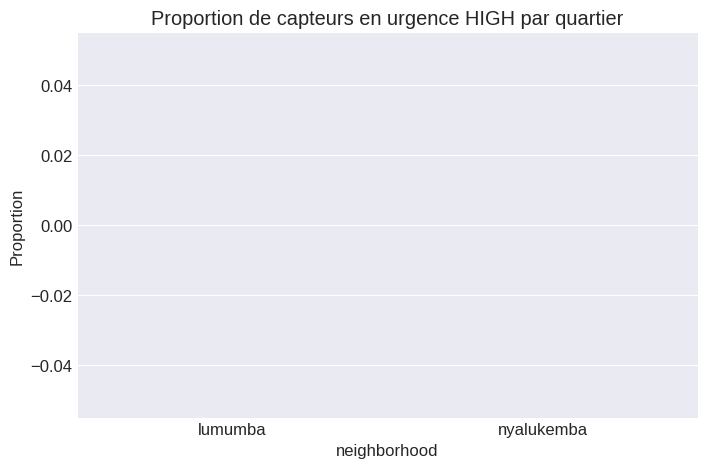


Collectes recommandées par semaine (exemple des dernières semaines) :
  neighborhood year_week  recommended_count
0      lumumba    2026-4                  0
1      lumumba    2026-5                  0
2      lumumba    2026-6                  0
3   nyalukemba   2025-46               1072
4   nyalukemba   2025-47                  0
5   nyalukemba   2025-48                  0

Collectes recommandées par mois :
  neighborhood year_month  recommended_count
0      lumumba    2026-01                  0
1      lumumba    2026-02                  0
2   nyalukemba    2025-11               1072


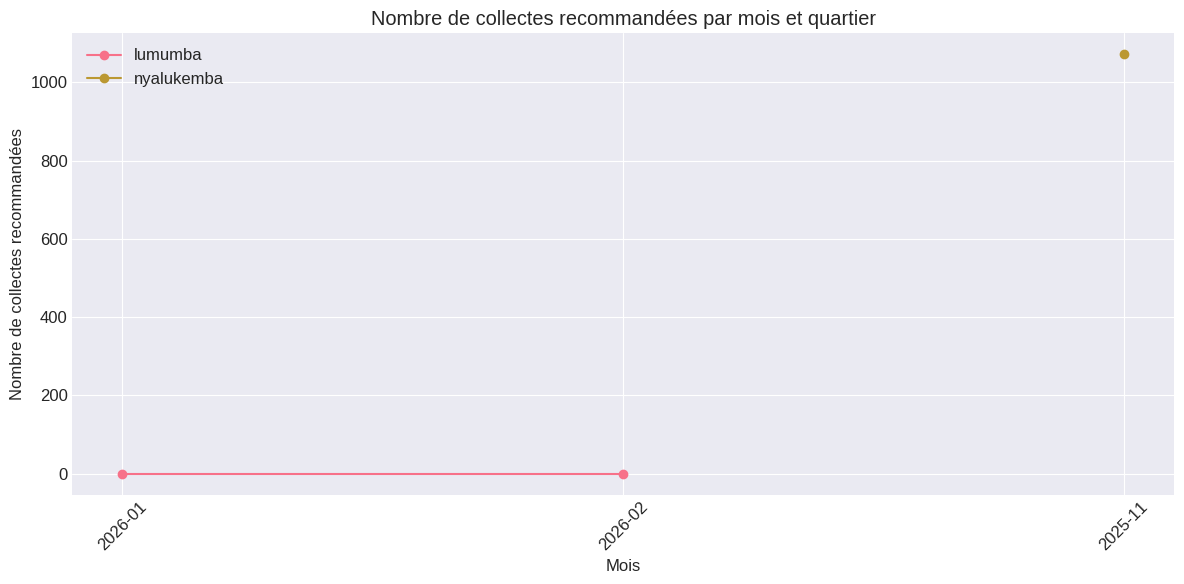


⚠️ Aucune donnée disponible pour l'analyse croisée : toutes les lignes ont des valeurs manquantes.
   Vérifiez que les colonnes 'collectionRecommended' et 'nextCollectionDate' contiennent des valeurs non nulles.


In [63]:
# 10. Urgency and collection recommendation analysis

# -----------------------------------------------------------------------------
# 2.1. Préparation : conversion des dates de collecte
# -----------------------------------------------------------------------------
# Convertir les colonnes de dates (si elles ne sont pas déjà au format datetime)
date_cols = ['lastCollectionDate', 'nextCollectionDate']
for col in date_cols:
    if col in df.columns:
        # Si la colonne est en millisecondes (valeur entière), convertir avec unit='ms'
        if df[col].dtype in ['int64', 'float64']:
            df[col] = pd.to_datetime(df[col], unit='ms', errors='coerce')
        else:
            df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f"Colonne {col} convertie en datetime.")

# Assurer que 'timestamp' est aussi datetime (si ce n'est pas déjà fait)
if 'timestamp' in df.columns and not pd.api.types.is_datetime64_any_dtype(df['timestamp']):
    if df['timestamp'].dtype in ['int64', 'float64']:
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms', errors='coerce')
    else:
        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    print("Colonne timestamp convertie en datetime.")

# -----------------------------------------------------------------------------
# 2.2. Proportion de capteurs en urgence (HIGH) par quartier
# -----------------------------------------------------------------------------
# Filtrer les lignes où collectionUrgency est renseigné
df_urgency = df[df['collectionUrgency'].notna()].copy()

# S'assurer que collectionUrgency est en majuscules (pour harmoniser)
df_urgency['collectionUrgency'] = df_urgency['collectionUrgency'].astype(str).str.upper()

# Calculer la proportion de HIGH par quartier
urgency_high_prop = df_urgency.groupby('neighborhood')['collectionUrgency'].apply(
    lambda x: (x == 'HIGH').sum() / len(x)
).reset_index(name='proportion_high')

print("\nProportion d'urgences HIGH par quartier :")
print(urgency_high_prop)

# Visualisation
plt.figure(figsize=(8,5))
sns.barplot(x='neighborhood', y='proportion_high', data=urgency_high_prop)
plt.title('Proportion de capteurs en urgence HIGH par quartier')
plt.ylabel('Proportion')
plt.show()

# -----------------------------------------------------------------------------
# 2.3. Nombre de collectes recommandées par semaine/mois, par quartier
# -----------------------------------------------------------------------------
# Filtrer les lignes où collectionRecommended est renseigné
df_rec = df[df['collectionRecommended'].notna()].copy()

# Convertir en booléen (True/False) si ce n'est pas déjà fait
df_rec['collectionRecommended'] = df_rec['collectionRecommended'].astype(str).str.lower().map({'true': True, 'false': False})

# Extraire des périodes (semaine et mois)
df_rec['year_week'] = df_rec['timestamp'].dt.isocalendar().year.astype(str) + '-' + df_rec['timestamp'].dt.isocalendar().week.astype(str)
df_rec['year_month'] = df_rec['timestamp'].dt.strftime('%Y-%m')

# Compter les recommandations par semaine et quartier
rec_weekly = df_rec.groupby(['neighborhood', 'year_week'])['collectionRecommended'].sum().reset_index(name='recommended_count')
# Compter par mois
rec_monthly = df_rec.groupby(['neighborhood', 'year_month'])['collectionRecommended'].sum().reset_index(name='recommended_count')

print("\nCollectes recommandées par semaine (exemple des dernières semaines) :")
print(rec_weekly.tail(10))

print("\nCollectes recommandées par mois :")
print(rec_monthly)

# Visualisation : série temporelle par quartier (mois)
plt.figure(figsize=(12,6))
for nb in rec_monthly['neighborhood'].unique():
    data = rec_monthly[rec_monthly['neighborhood'] == nb].sort_values('year_month')
    plt.plot(data['year_month'], data['recommended_count'], marker='o', label=nb)
plt.xticks(rotation=45)
plt.xlabel('Mois')
plt.ylabel('Nombre de collectes recommandées')
plt.title('Nombre de collectes recommandées par mois et quartier')
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 2.4. Analyse des faux positifs/négatifs (croisement avec dates de collecte réelles)
# -----------------------------------------------------------------------------
# Nous utilisons nextCollectionDate comme date de collecte effective.
# Pour chaque ligne avec collectionRecommended, on définit un intervalle de confiance
# (par ex. 3 jours avant/après la date de collecte réelle) pour juger de la pertinence de la recommandation.

# Créer une copie avec les dates de collecte
df_cross = df_rec[['timestamp', 'neighborhood', 'collectionRecommended', 'nextCollectionDate']].copy()
df_cross = df_cross.dropna(subset=['collectionRecommended', 'nextCollectionDate']).copy()

# Vérifier qu'il reste des données pour l'analyse croisée
if df_cross.empty:
    print("\n⚠️ Aucune donnée disponible pour l'analyse croisée : toutes les lignes ont des valeurs manquantes.")
    print("   Vérifiez que les colonnes 'collectionRecommended' et 'nextCollectionDate' contiennent des valeurs non nulles.")
else:
    # Définir une fenêtre de tolérance (en jours)
    tolerance_days = 3

    # Pour chaque ligne, vérifier si une collecte réelle a eu lieu dans la fenêtre autour de la recommandation
    df_cross['actual_collection_within_window'] = (
        (df_cross['nextCollectionDate'] - df_cross['timestamp']).dt.total_seconds().abs() <= tolerance_days * 86400
    )

    # Construire la matrice de confusion
    from sklearn.metrics import confusion_matrix
    y_true = df_cross['actual_collection_within_window'].astype(bool)  # 1 = collecte effective, 0 = pas de collecte
    y_pred = df_cross['collectionRecommended'].astype(bool)            # 1 = recommandation, 0 = pas de recommandation

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print("\n=== Analyse des faux positifs/négatifs ===")
    print(f"Fenêtre de tolérance : {tolerance_days} jours")
    print(f"Vrais positifs (collecte effective et recommandée) : {tp}")
    print(f"Faux positifs (recommandation sans collecte effective) : {fp}")
    print(f"Faux négatifs (collecte effective sans recommandation) : {fn}")
    print(f"Vrais négatifs (pas de collecte et pas de recommandation) : {tn}")

    # Taux de faux positifs et faux négatifs
    if (tp + fp) > 0:
        fpr = fp / (tp + fp)
        print(f"Taux de faux positifs (FPR) : {fpr:.2%}")
    if (tp + fn) > 0:
        fnr = fn / (tp + fn)
        print(f"Taux de faux négatifs (FNR) : {fnr:.2%}")

    # Analyse par quartier
    print("\nAnalyse par quartier :")
    for nb in df_cross['neighborhood'].unique():
        sub = df_cross[df_cross['neighborhood'] == nb]
        y_true_sub = sub['actual_collection_within_window'].astype(bool)
        y_pred_sub = sub['collectionRecommended'].astype(bool)
        tn, fp, fn, tp = confusion_matrix(y_true_sub, y_pred_sub).ravel()
        print(f"\nQuartier {nb}: TP={tp}, FP={fp}, FN={fn}, TN={tn}")
        if (tp+fp) > 0:
            print(f"  FPR = {fp/(tp+fp):.2%}")
        if (tp+fn) > 0:
            print(f"  FNR = {fn/(tp+fn):.2%}")

    # Visualisation : histogramme des délais entre recommandation et collecte réelle
    df_cross['delay_days'] = (df_cross['nextCollectionDate'] - df_cross['timestamp']).dt.total_seconds() / 86400
    plt.figure(figsize=(10,5))
    plt.hist(df_cross['delay_days'], bins=50, alpha=0.7)
    plt.axvline(x=0, color='r', linestyle='--')
    plt.axvline(x=tolerance_days, color='g', linestyle='--', label=f'Fenêtre +/-{tolerance_days}j')
    plt.axvline(x=-tolerance_days, color='g', linestyle='--')
    plt.xlabel('Délai (jours) entre recommandation et collecte réelle')
    plt.ylabel("Nombre d'observations")
    plt.title('Distribution des délais recommandation → collecte réelle')
    plt.legend()
    plt.show()

=== Nombre moyen d'ouvertures par quartier ===
  neighborhood  dailyOpenings  nightlyOpenings  total_openings
0      lumumba       0.009422              0.0        0.009422
1   nyalukemba       0.033384              0.0        0.033384


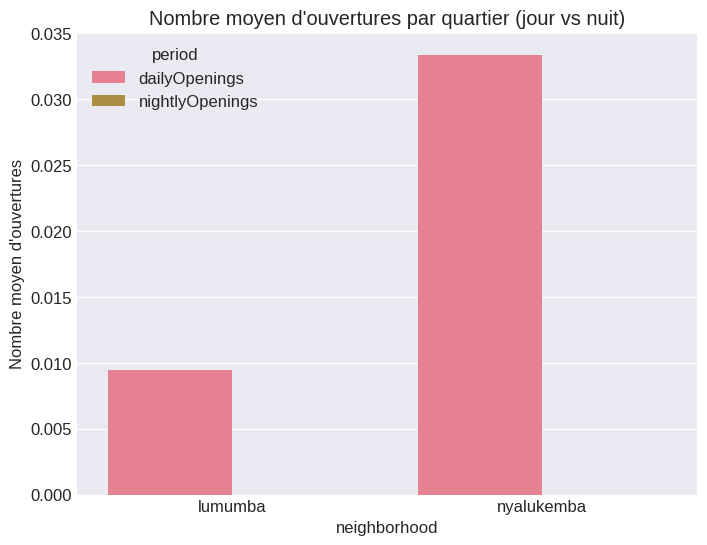


=== Statistiques d'efficacité par quartier ===
             depositEfficiency              calculated_efficiency          \
                          mean   std  count                  mean     std   
neighborhood                                                                
lumumba                  5.665  0.44   4834                22.816   0.805   
nyalukemba              11.987  8.41  42757               257.063  48.123   

                     
              count  
neighborhood         
lumumba        4828  
nyalukemba    22030  


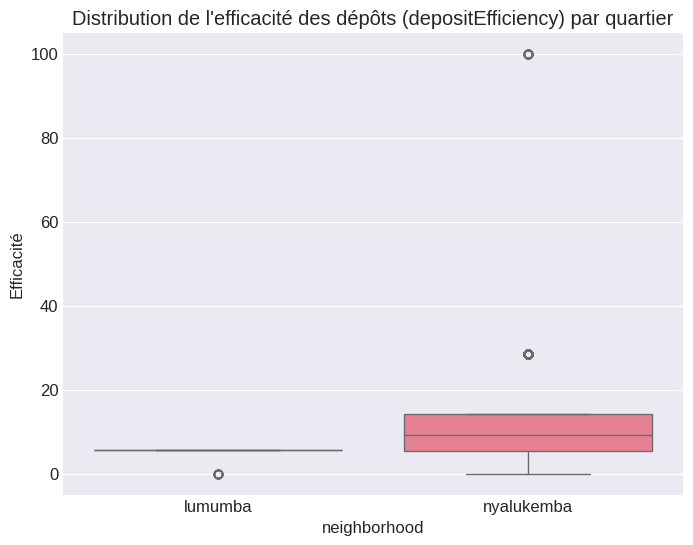


=== Corrélation globale (tous quartiers) ===
                   dailyOpenings  nightlyOpenings  wasteVolumeLiters
dailyOpenings           1.000000              NaN           0.506803
nightlyOpenings              NaN              NaN                NaN
wasteVolumeLiters       0.506803              NaN           1.000000

=== Corrélations par quartier ===

Quartier nyalukemba:
                   dailyOpenings  nightlyOpenings  wasteVolumeLiters
dailyOpenings           1.000000              NaN           0.351183
nightlyOpenings              NaN              NaN                NaN
wasteVolumeLiters       0.351183              NaN           1.000000

Quartier lumumba:
                   dailyOpenings  nightlyOpenings  wasteVolumeLiters
dailyOpenings           1.000000              NaN          -0.019966
nightlyOpenings              NaN              NaN                NaN
wasteVolumeLiters      -0.019966              NaN           1.000000


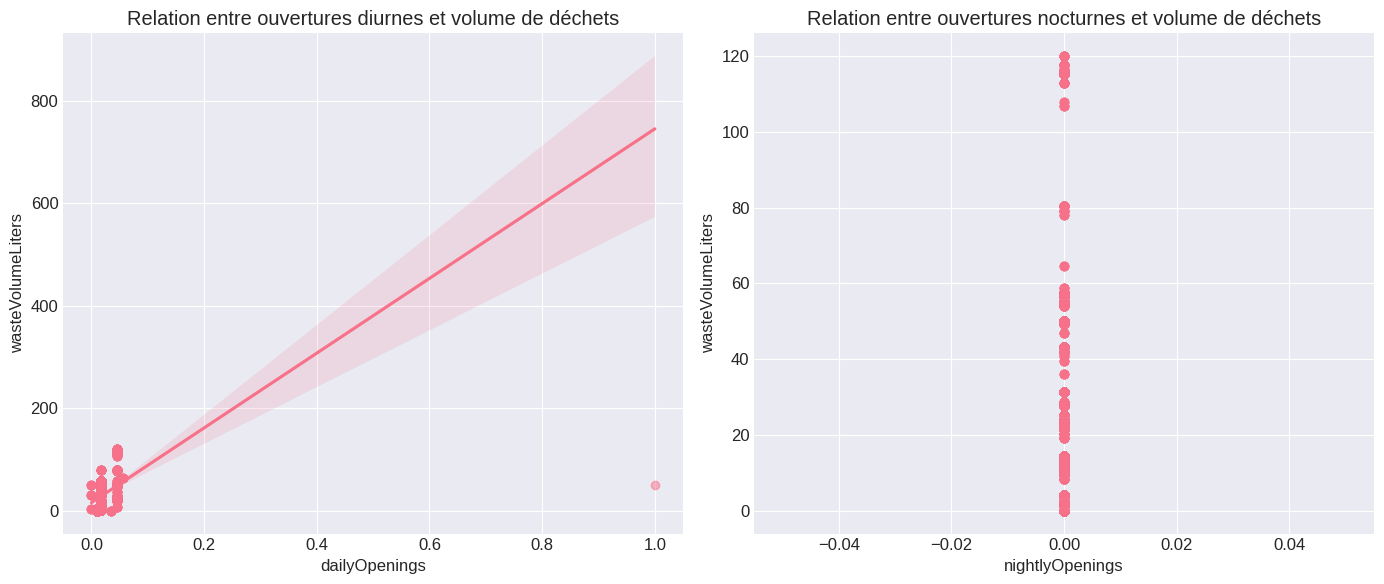


=== Ratio dépôts par ouverture (efficacité observée) ===
  neighborhood  mean_deposits_per_opening  std_deposits_per_opening
0      lumumba                 582.481111                  0.804924
1   nyalukemba                 351.190437                 48.122734


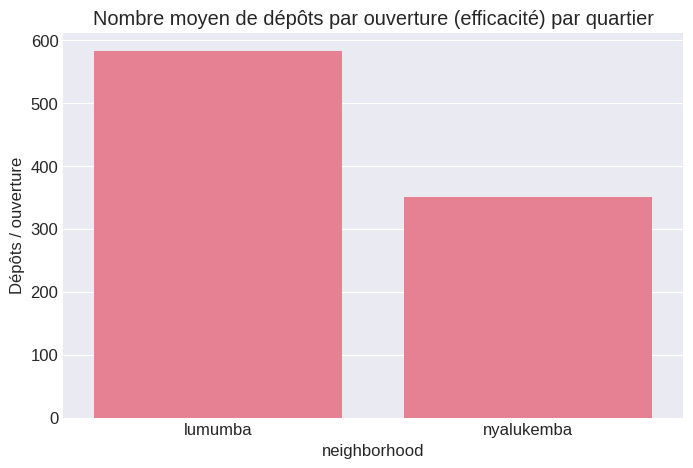

In [41]:
# 11. Usage frequency and deposit effectiveness analysis

# -----------------------------------------------------------------------------
# 3.1. Préparation des données pour cette analyse
# -----------------------------------------------------------------------------
# Sous-ensemble avec les colonnes nécessaires
cols_usage = ['neighborhood', 'dailyOpenings', 'nightlyOpenings', 'deposits', 'depositEfficiency', 'wasteVolumeLiters']
df_usage = df[cols_usage].copy()

# Supprimer les lignes où toutes les colonnes d'intérêt sont NaN (on garde au moins une)
df_usage = df_usage.dropna(subset=['dailyOpenings', 'nightlyOpenings', 'deposits', 'depositEfficiency'], how='all')

# Convertir les colonnes numériques (si ce n'est pas déjà fait, mais normalement oui)
numeric_usage = ['dailyOpenings', 'nightlyOpenings', 'deposits', 'depositEfficiency', 'wasteVolumeLiters']
for col in numeric_usage:
    if col in df_usage.columns:
        df_usage[col] = pd.to_numeric(df_usage[col], errors='coerce')

# -----------------------------------------------------------------------------
# 3.2. Nombre moyen d’ouvertures par jour/nuit par quartier
# -----------------------------------------------------------------------------
# Calcul des moyennes par quartier
mean_openings = df_usage.groupby('neighborhood')[['dailyOpenings', 'nightlyOpenings']].mean().reset_index()
mean_openings['total_openings'] = mean_openings['dailyOpenings'] + mean_openings['nightlyOpenings']

print("=== Nombre moyen d'ouvertures par quartier ===")
print(mean_openings)

# Visualisation : barplot groupé
plt.figure(figsize=(8,6))
mean_openings_melted = mean_openings.melt(id_vars='neighborhood', value_vars=['dailyOpenings', 'nightlyOpenings'],
                                          var_name='period', value_name='mean_openings')
sns.barplot(x='neighborhood', y='mean_openings', hue='period', data=mean_openings_melted)
plt.title('Nombre moyen d\'ouvertures par quartier (jour vs nuit)')
plt.ylabel('Nombre moyen d\'ouvertures')
plt.show()

# -----------------------------------------------------------------------------
# 3.3. Efficacité des dépôts
# -----------------------------------------------------------------------------
# Calculer l'efficacité observée (deposits / (dailyOpenings+nightlyOpenings)) si depositEfficiency n'est pas fiable
df_usage['calculated_efficiency'] = df_usage['deposits'] / (df_usage['dailyOpenings'] + df_usage['nightlyOpenings'])
df_usage['calculated_efficiency'] = df_usage['calculated_efficiency'].replace([np.inf, -np.inf], np.nan)  # éviter division par zéro

# Statistiques par quartier
efficiency_stats = df_usage.groupby('neighborhood')[['depositEfficiency', 'calculated_efficiency']].agg(['mean', 'std', 'count']).round(3)
print("\n=== Statistiques d'efficacité par quartier ===")
print(efficiency_stats)

# Boxplots pour comparer depositEfficiency
plt.figure(figsize=(8,6))
sns.boxplot(x='neighborhood', y='depositEfficiency', data=df_usage)
plt.title('Distribution de l\'efficacité des dépôts (depositEfficiency) par quartier')
plt.ylabel('Efficacité')
plt.show()

# -----------------------------------------------------------------------------
# 3.4. Corrélation entre ouvertures et volume de déchets
# -----------------------------------------------------------------------------
# On filtre les lignes où wasteVolumeLiters est disponible
df_corr = df_usage[['neighborhood', 'dailyOpenings', 'nightlyOpenings', 'wasteVolumeLiters']].dropna()
if len(df_corr) > 0:
    # Calcul de la corrélation globale (toutes données confondues)
    corr_matrix = df_corr[['dailyOpenings', 'nightlyOpenings', 'wasteVolumeLiters']].corr()
    print("\n=== Corrélation globale (tous quartiers) ===")
    print(corr_matrix)

    # Par quartier
    print("\n=== Corrélations par quartier ===")
    for nb in df_corr['neighborhood'].unique():
        sub = df_corr[df_corr['neighborhood'] == nb][['dailyOpenings', 'nightlyOpenings', 'wasteVolumeLiters']]
        if len(sub) > 2:
            corr_sub = sub.corr()
            print(f"\nQuartier {nb}:")
            print(corr_sub)

    # Visualisation : scatter plot avec droite de régression
    fig, axes = plt.subplots(1, 2, figsize=(14,6))
    # Daily openings vs volume
    sns.regplot(x='dailyOpenings', y='wasteVolumeLiters', data=df_corr, ax=axes[0], scatter_kws={'alpha':0.5})
    axes[0].set_title('Relation entre ouvertures diurnes et volume de déchets')
    # Nightly openings vs volume
    sns.regplot(x='nightlyOpenings', y='wasteVolumeLiters', data=df_corr, ax=axes[1], scatter_kws={'alpha':0.5})
    axes[1].set_title('Relation entre ouvertures nocturnes et volume de déchets')
    plt.tight_layout()
    plt.show()
else:
    print("Pas assez de données pour la corrélation (wasteVolumeLiters manquant).")

# -----------------------------------------------------------------------------
# 3.5. Analyse complémentaire : ratio dépôts par ouverture (efficacité) selon le quartier
# -----------------------------------------------------------------------------
# On calcule le ratio moyen par quartier
ratio_stats = df_usage.groupby('neighborhood').apply(
    lambda x: pd.Series({
        'mean_deposits_per_opening': (x['deposits'].sum() / (x['dailyOpenings'].sum() + x['nightlyOpenings'].sum())) if (x['dailyOpenings'].sum() + x['nightlyOpenings'].sum()) > 0 else np.nan,
        'std_deposits_per_opening': x['calculated_efficiency'].std()
    })
).reset_index()

print("\n=== Ratio dépôts par ouverture (efficacité observée) ===")
print(ratio_stats)

# Visualisation
plt.figure(figsize=(8,5))
sns.barplot(x='neighborhood', y='mean_deposits_per_opening', data=ratio_stats)
plt.title('Nombre moyen de dépôts par ouverture (efficacité) par quartier')
plt.ylabel('Dépôts / ouverture')
plt.show()

=== Production moyenne par quartier (par jour) ===
  neighborhood  wasteVolumeLiters  wasteWeightKg  totalWeightKg
0      lumumba          25.450329       4.596514       9.463046
1   nyalukemba          15.719116       3.140373       7.961533


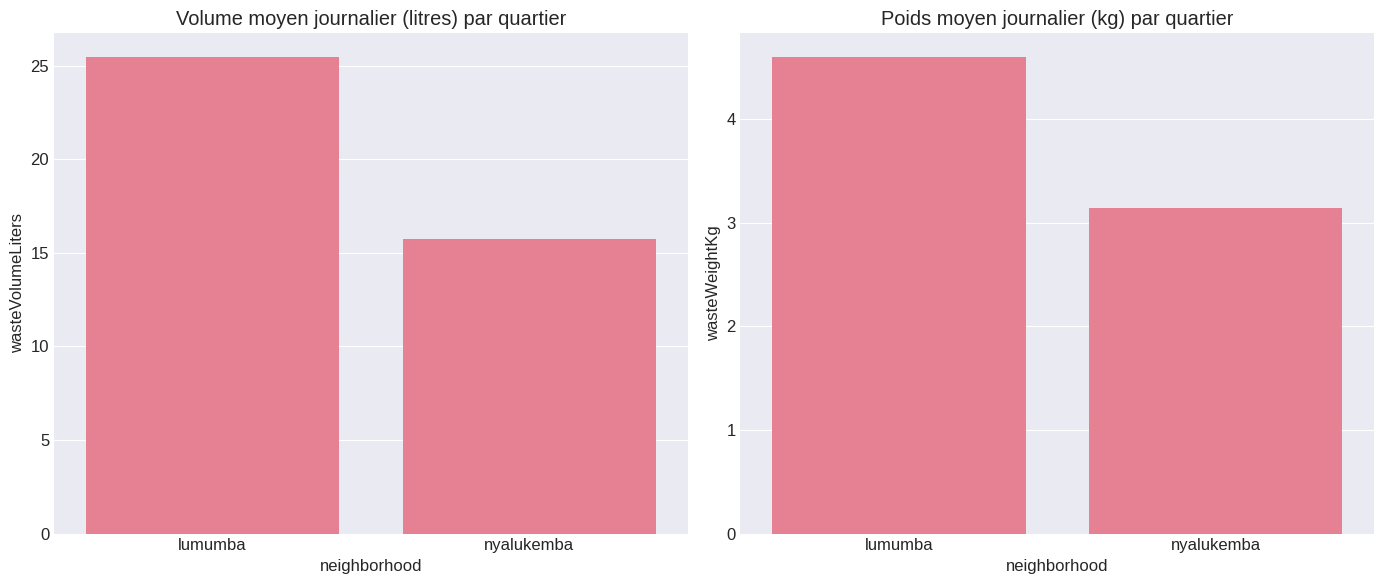

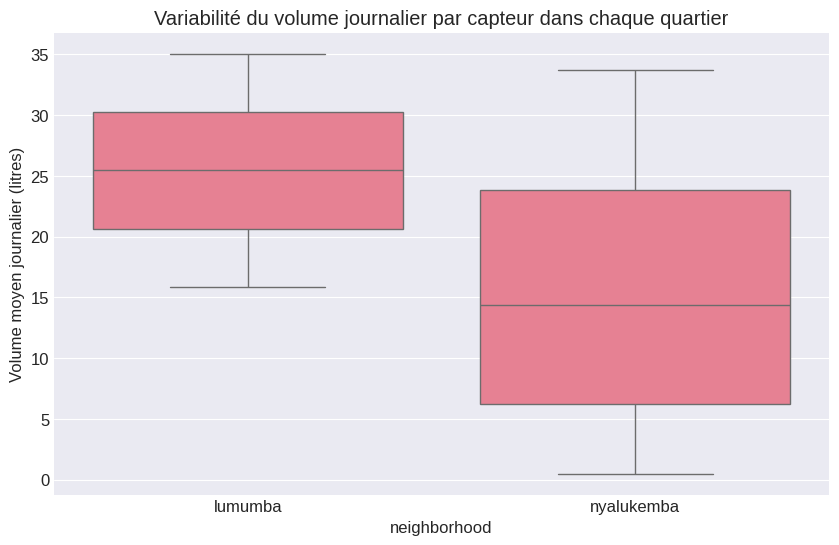


=== Coefficient de variation intra-quartier ===
  neighborhood  cv_volume  cv_weight
0      lumumba   0.533568   0.435685
1   nyalukemba   0.926615   0.927122

=== Projection des besoins de capacité (percentiles de production journalière par quartier) ===
              wasteVolumeLiters_p50  wasteVolumeLiters_p75  \
neighborhood                                                 
lumumba               154048.647775          258014.124581   
nyalukemba            166230.547569          197814.017341   

              wasteVolumeLiters_p90  wasteVolumeLiters_p95  \
neighborhood                                                 
lumumba               346174.993891          383577.347938   
nyalukemba            438852.438478          612913.361218   

              wasteVolumeLiters_p99  wasteWeightKg_p50  wasteWeightKg_p75  \
neighborhood                                                                
lumumba               393150.053770       29379.713035       44880.222221   
nyalukemba    

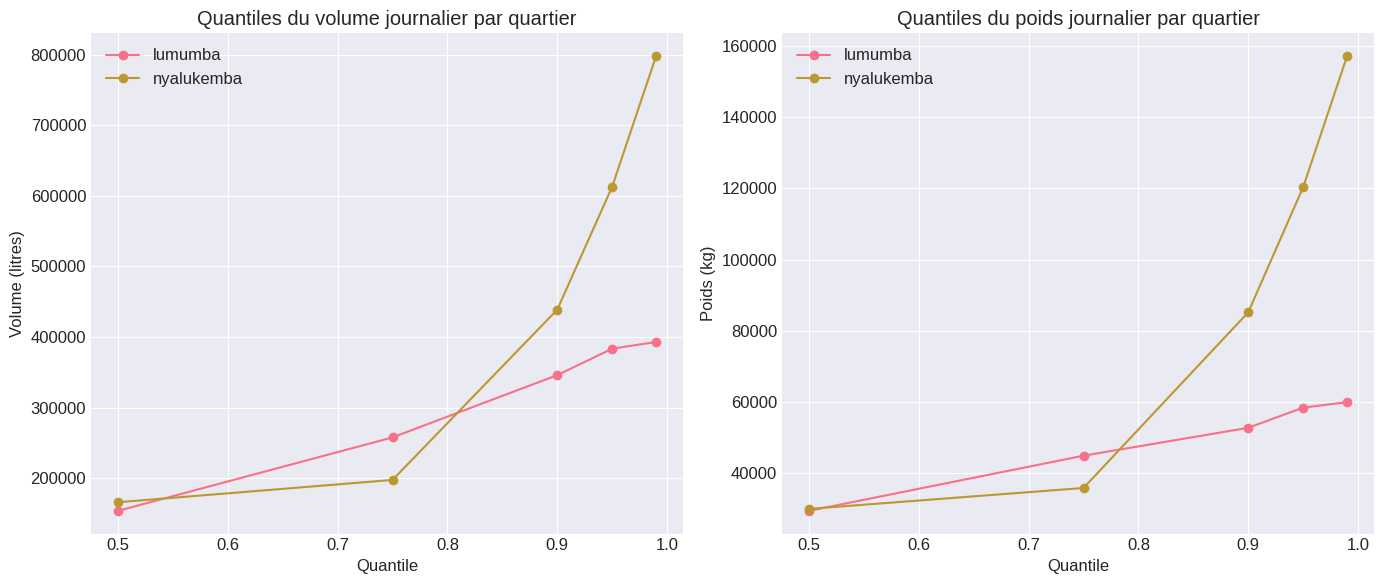


=== Recommandations pour l'optimisation des collectes ===
- lumumba: Données insuffisantes pour estimer la capacité.
- nyalukemba: Données insuffisantes pour estimer la capacité.


In [64]:
# 12. Waste production analysis (volume and weight)

# -----------------------------------------------------------------------------
# 4.1. Préparation des données pour cette analyse
# -----------------------------------------------------------------------------
# Colonnes nécessaires
waste_cols = ['timestamp', 'name', 'neighborhood', 'wasteVolumeLiters', 'wasteWeightKg', 'totalWeightKg']
df_waste = df[waste_cols].copy()

# Filtrer les lignes où au moins une mesure de déchet est présente
df_waste = df_waste[df_waste['wasteVolumeLiters'].notna() | df_waste['wasteWeightKg'].notna() | df_waste['totalWeightKg'].notna()]

# Convertir en numérique (si nécessaire)
for col in ['wasteVolumeLiters', 'wasteWeightKg', 'totalWeightKg']:
    df_waste[col] = pd.to_numeric(df_waste[col], errors='coerce')

# Extraire la date (sans heure) pour agréger par jour
df_waste['date'] = df_waste['timestamp'].dt.date

# -----------------------------------------------------------------------------
# 4.2. Production moyenne par capteur et par quartier (kg/jour, L/jour)
# -----------------------------------------------------------------------------
# Grouper par capteur et par jour pour obtenir les quantités quotidiennes
daily_sensor = df_waste.groupby(['name', 'date'])[['wasteVolumeLiters', 'wasteWeightKg', 'totalWeightKg']].mean().reset_index()

# Production moyenne quotidienne par capteur (tous les jours confondus)
sensor_avg = daily_sensor.groupby('name')[['wasteVolumeLiters', 'wasteWeightKg', 'totalWeightKg']].mean().reset_index()

# Ajouter le quartier de chaque capteur (en prenant la première occurrence non nulle)
neighborhood_map = df_waste.groupby('name')['neighborhood'].first().reset_index()
sensor_avg = sensor_avg.merge(neighborhood_map, on='name', how='left')

# Production moyenne par quartier
neighborhood_avg = sensor_avg.groupby('neighborhood')[['wasteVolumeLiters', 'wasteWeightKg', 'totalWeightKg']].mean().reset_index()

print("=== Production moyenne par quartier (par jour) ===")
print(neighborhood_avg)

# Visualisation : barplot comparatif
fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.barplot(x='neighborhood', y='wasteVolumeLiters', data=neighborhood_avg, ax=axes[0])
axes[0].set_title('Volume moyen journalier (litres) par quartier')
sns.barplot(x='neighborhood', y='wasteWeightKg', data=neighborhood_avg, ax=axes[1])
axes[1].set_title('Poids moyen journalier (kg) par quartier')
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 4.3. Variabilité intra-quartier (certains conteneurs sont-ils plus sollicités ?)
# -----------------------------------------------------------------------------
# Distribution des moyennes par capteur au sein de chaque quartier
plt.figure(figsize=(10,6))
sns.boxplot(x='neighborhood', y='wasteVolumeLiters', data=sensor_avg)
plt.title('Variabilité du volume journalier par capteur dans chaque quartier')
plt.ylabel('Volume moyen journalier (litres)')
plt.show()

# Coefficient de variation (écart-type / moyenne) pour mesurer la dispersion relative
cv_volume = sensor_avg.groupby('neighborhood')['wasteVolumeLiters'].agg(lambda x: x.std() / x.mean() if x.mean() > 0 else np.nan).reset_index(name='cv_volume')
cv_weight = sensor_avg.groupby('neighborhood')['wasteWeightKg'].agg(lambda x: x.std() / x.mean() if x.mean() > 0 else np.nan).reset_index(name='cv_weight')
print("\n=== Coefficient de variation intra-quartier ===")
print(cv_volume.merge(cv_weight, on='neighborhood'))

# -----------------------------------------------------------------------------
# 4.4. Projection des besoins de capacité
# -----------------------------------------------------------------------------
# Pour chaque quartier, calculer les percentiles de production journalière (pour dimensionner les conteneurs)
# On utilise les données journalières par capteur (mais pour la projection, on peut aussi utiliser les données brutes par capteur)
daily_quarter = df_waste.groupby(['neighborhood', 'date'])[['wasteVolumeLiters', 'wasteWeightKg']].sum().reset_index()

percentiles = [0.5, 0.75, 0.9, 0.95, 0.99]
projection = daily_quarter.groupby('neighborhood')[['wasteVolumeLiters', 'wasteWeightKg']].quantile(percentiles).unstack()
projection.columns = [f"{col}_p{int(p*100)}" for col, p in projection.columns]
print("\n=== Projection des besoins de capacité (percentiles de production journalière par quartier) ===")
print(projection)

# Visualisation : évolution des quantiles
fig, axes = plt.subplots(1, 2, figsize=(14,6))
for nb in daily_quarter['neighborhood'].unique():
    data = daily_quarter[daily_quarter['neighborhood'] == nb]
    quantiles_vol = data['wasteVolumeLiters'].quantile([0.5,0.75,0.9,0.95,0.99])
    quantiles_wgt = data['wasteWeightKg'].quantile([0.5,0.75,0.9,0.95,0.99])
    axes[0].plot(quantiles_vol.index, quantiles_vol.values, marker='o', label=nb)
    axes[1].plot(quantiles_wgt.index, quantiles_wgt.values, marker='o', label=nb)
axes[0].set_title('Quantiles du volume journalier par quartier')
axes[0].set_xlabel('Quantile')
axes[0].set_ylabel('Volume (litres)')
axes[0].legend()
axes[1].set_title('Quantiles du poids journalier par quartier')
axes[1].set_xlabel('Quantile')
axes[1].set_ylabel('Poids (kg)')
axes[1].legend()
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 4.5. Recommandations basées sur les projections (exemple)
# -----------------------------------------------------------------------------
print("\n=== Recommandations pour l'optimisation des collectes ===")
for nb in projection.index:
    vol_95 = projection.loc[nb, 'wasteVolumeLiters_p95.0'] if 'wasteVolumeLiters_p95.0' in projection.columns else None
    if vol_95 and vol_95 > 0:
        print(f"- {nb}: 95% des jours produisent moins de {vol_95:.0f} litres. Capacité minimale recommandée : {vol_95:.0f} L (pour éviter un débordement un jour sur vingt).")
    else:
        print(f"- {nb}: Données insuffisantes pour estimer la capacité.")

=== Statistiques de la batterie par quartier ===
              mean  std   min    max  count
neighborhood                               
lumumba       89.2  0.8   0.0   90.0  58635
nyalukemba    86.9  3.6  84.0  100.0  97707


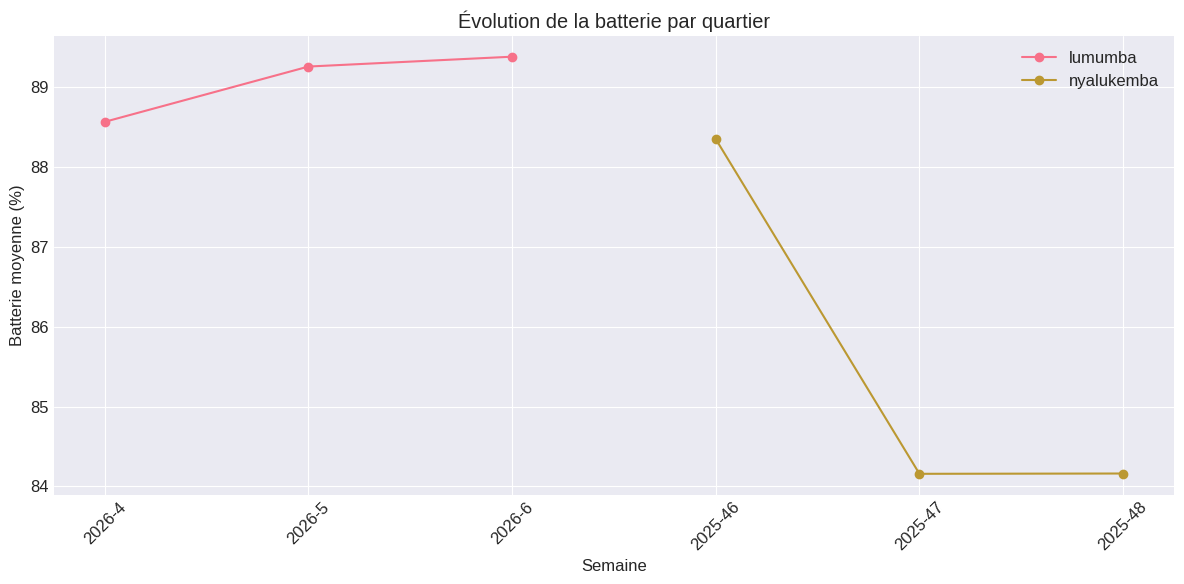


=== Alertes batterie faible (<20%) ===
Nombre de capteurs concernés : 3
                       name  low_battery_count  last_battery  \
0  sensor2-24e124713c245638                  1           0.0   
1  sensor5-24e124713c245531                  1           0.0   
2  sensor7-24e124713c245085                  1           0.0   

           last_timestamp neighborhood  
0 2026-01-29 22:26:06.594      lumumba  
1 2026-01-27 13:26:06.009      lumumba  
2 2026-01-25 16:41:47.151      lumumba  

=== Alertes comportement anormal (score <50) ===
Nombre de capteurs concernés : 0
Empty DataFrame
Columns: [name, low_behavior_count, last_behavior, last_timestamp, neighborhood]
Index: []


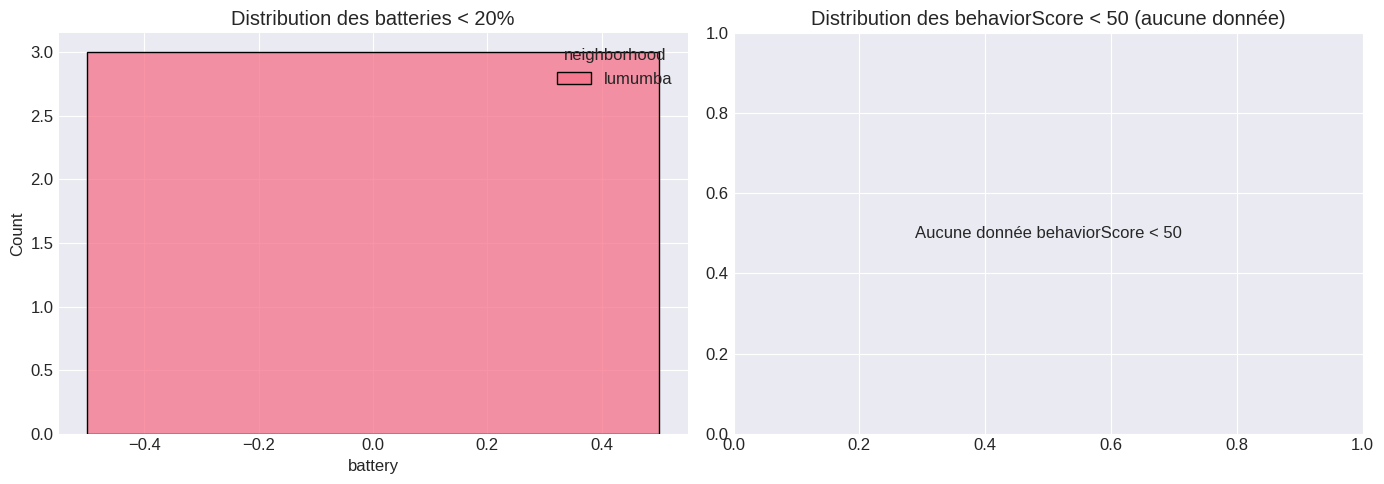


=== Moyennes des indicateurs par quartier (par capteur) ===
              mean_battery  mean_behavior
neighborhood                             
lumumba          87.416100      72.198098
nyalukemba       90.631316      72.606541

ANOVA batterie : F = 3.503, p = 0.1346
ANOVA behaviorScore : F = 0.182, p = 0.6875


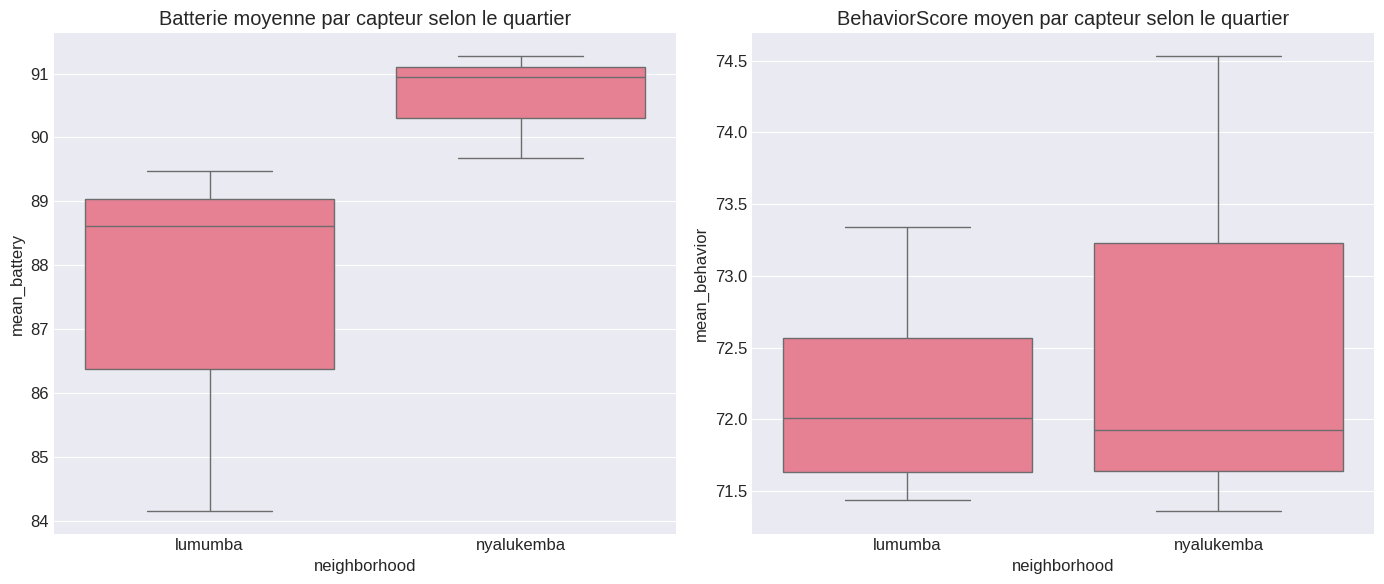

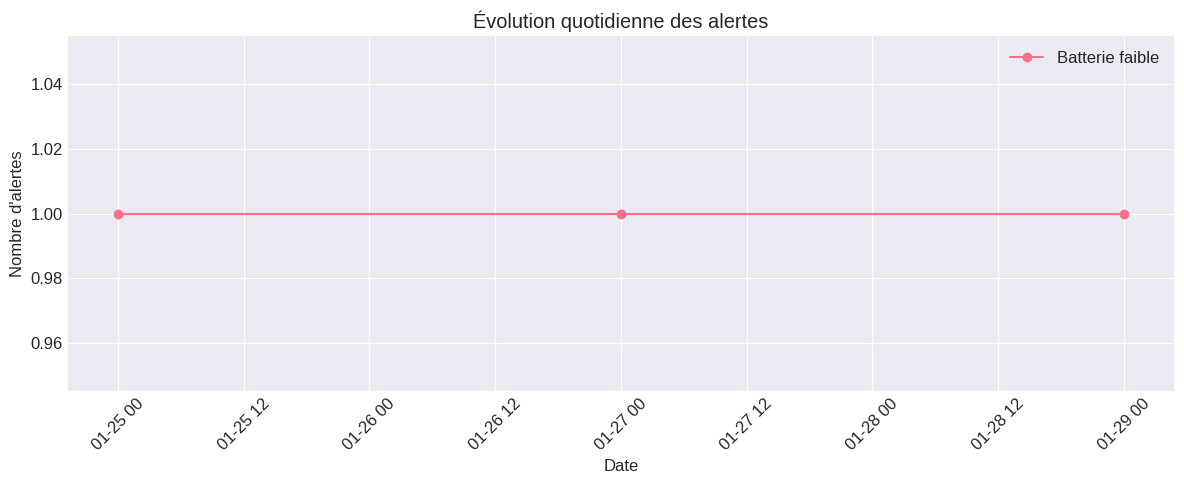


=== Recommandations pour la maintenance ===
Capteurs nécessitant un remplacement immédiat (batterie moyenne < 20%) :
Empty DataFrame
Columns: [name, neighborhood, mean_battery]
Index: []

Capteurs avec comportement anormal (score moyen < 50) :
Empty DataFrame
Columns: [name, neighborhood, mean_behavior]
Index: []

Capteurs avec dégradation rapide de la batterie (pente < -0.1 par jour) :
Empty DataFrame
Columns: [name, battery_slope, p_value]
Index: []


In [65]:
# 13. Sensor performance and maintenance analysis

# Imports nécessaires
# -----------------------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, linregress  # pour ANOVA et régression

# (On suppose que le DataFrame df existe déjà avec les colonnes appropriées)

# -----------------------------------------------------------------------------
# 5.1. Préparation des données pour cette analyse
# -----------------------------------------------------------------------------
# Colonnes nécessaires
perf_cols = ['timestamp', 'name', 'neighborhood', 'battery', 'behaviorScore']
df_perf = df[perf_cols].copy()

# Filtrer les lignes où au moins une mesure de performance est présente
df_perf = df_perf[df_perf['battery'].notna() | df_perf['behaviorScore'].notna()]

# Convertir en numérique (déjà fait normalement, mais sécurité)
df_perf['battery'] = pd.to_numeric(df_perf['battery'], errors='coerce')
df_perf['behaviorScore'] = pd.to_numeric(df_perf['behaviorScore'], errors='coerce')

# Extraire la date (pour agrégation temporelle)
df_perf['date'] = df_perf['timestamp'].dt.date

# -----------------------------------------------------------------------------
# 5.2. Suivi de l’autonomie des capteurs par quartier
# -----------------------------------------------------------------------------
# Statistiques générales de batterie par quartier
battery_stats = df_perf.groupby('neighborhood')['battery'].agg(['mean', 'std', 'min', 'max', 'count']).round(1)
print("=== Statistiques de la batterie par quartier ===")
print(battery_stats)

# Évolution temporelle de la batterie (moyenne par semaine)
df_perf['year_week'] = df_perf['timestamp'].dt.isocalendar().year.astype(str) + '-' + df_perf['timestamp'].dt.isocalendar().week.astype(str)
weekly_battery = df_perf.groupby(['neighborhood', 'year_week'])['battery'].mean().reset_index()

# Tracer l'évolution pour chaque quartier
plt.figure(figsize=(12,6))
for nb in weekly_battery['neighborhood'].unique():
    data = weekly_battery[weekly_battery['neighborhood'] == nb].sort_values('year_week')
    plt.plot(data['year_week'], data['battery'], marker='o', label=nb)
plt.xticks(rotation=45)
plt.xlabel('Semaine')
plt.ylabel('Batterie moyenne (%)')
plt.title('Évolution de la batterie par quartier')
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 5.3. Alertes sur les capteurs avec batterie faible ou comportement anormal
# -----------------------------------------------------------------------------
# Définir des seuils (ajustables)
battery_threshold = 20   # % (alerte faible)
behavior_threshold = 50  # score (alerte anormal)

# Détection des capteurs avec batterie faible
low_battery = df_perf[df_perf['battery'] < battery_threshold].copy()
# Grouper par capteur pour compter les occurrences
low_battery_summary = low_battery.groupby('name').agg(
    low_battery_count=('battery', 'count'),
    last_battery=('battery', 'last'),
    last_timestamp=('timestamp', 'last'),
    neighborhood=('neighborhood', 'first')
).reset_index()
low_battery_summary = low_battery_summary.sort_values('low_battery_count', ascending=False)

print(f"\n=== Alertes batterie faible (<{battery_threshold}%) ===")
print(f"Nombre de capteurs concernés : {low_battery_summary['name'].nunique()}")
print(low_battery_summary.head(10))

# Détection des capteurs avec comportement anormal
low_behavior = df_perf[df_perf['behaviorScore'] < behavior_threshold].copy()
low_behavior_summary = low_behavior.groupby('name').agg(
    low_behavior_count=('behaviorScore', 'count'),
    last_behavior=('behaviorScore', 'last'),
    last_timestamp=('timestamp', 'last'),
    neighborhood=('neighborhood', 'first')
).reset_index()
low_behavior_summary = low_behavior_summary.sort_values('low_behavior_count', ascending=False)

print(f"\n=== Alertes comportement anormal (score <{behavior_threshold}) ===")
print(f"Nombre de capteurs concernés : {low_behavior_summary['name'].nunique()}")
print(low_behavior_summary.head(10))

# Visualisation : distribution des valeurs faibles par quartier
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Sous-graphique batterie faible
battery_low_data = df_perf[df_perf['battery'] < battery_threshold]
if not battery_low_data.empty:
    sns.histplot(data=battery_low_data, x='battery', hue='neighborhood', ax=axes[0], multiple='stack')
    axes[0].set_title(f'Distribution des batteries < {battery_threshold}%')
else:
    axes[0].text(0.5, 0.5, f'Aucune donnée batterie < {battery_threshold}%',
                 horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)
    axes[0].set_title(f'Distribution des batteries < {battery_threshold}% (aucune donnée)')

# Sous-graphique comportement faible
behavior_low_data = df_perf[df_perf['behaviorScore'] < behavior_threshold]
if not behavior_low_data.empty:
    sns.histplot(data=behavior_low_data, x='behaviorScore', hue='neighborhood', ax=axes[1], multiple='stack')
    axes[1].set_title(f'Distribution des behaviorScore < {behavior_threshold}')
else:
    axes[1].text(0.5, 0.5, f'Aucune donnée behaviorScore < {behavior_threshold}',
                 horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)
    axes[1].set_title(f'Distribution des behaviorScore < {behavior_threshold} (aucune donnée)')

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 5.4. Corrélation entre environnement (quartier) et usure des capteurs
# -----------------------------------------------------------------------------
# On calcule pour chaque capteur : batterie moyenne, comportement moyen, nombre de relevés
sensor_perf = df_perf.groupby('name').agg(
    mean_battery=('battery', 'mean'),
    mean_behavior=('behaviorScore', 'mean'),
    count_battery=('battery', 'count'),
    count_behavior=('behaviorScore', 'count'),
    neighborhood=('neighborhood', 'first')
).reset_index()

# Supprimer les capteurs sans données suffisantes (par ex. < 5 mesures)
sensor_perf = sensor_perf[(sensor_perf['count_battery'] >= 5) | (sensor_perf['count_behavior'] >= 5)]

# Comparer les moyennes par quartier
avg_by_hood = sensor_perf.groupby('neighborhood')[['mean_battery', 'mean_behavior']].mean()
print("\n=== Moyennes des indicateurs par quartier (par capteur) ===")
print(avg_by_hood)

# Test ANOVA pour savoir si les différences sont significatives
# Batterie
battery_groups = [sensor_perf[sensor_perf['neighborhood'] == nb]['mean_battery'].dropna() for nb in sensor_perf['neighborhood'].unique()]
if len(battery_groups) >= 2 and all(len(g) > 0 for g in battery_groups):
    f_batt, p_batt = f_oneway(*battery_groups)
    print(f"\nANOVA batterie : F = {f_batt:.3f}, p = {p_batt:.4f}")

# BehaviorScore
behavior_groups = [sensor_perf[sensor_perf['neighborhood'] == nb]['mean_behavior'].dropna() for nb in sensor_perf['neighborhood'].unique()]
if len(behavior_groups) >= 2 and all(len(g) > 0 for g in behavior_groups):
    f_beh, p_beh = f_oneway(*behavior_groups)
    print(f"ANOVA behaviorScore : F = {f_beh:.3f}, p = {p_beh:.4f}")

# Visualisation : boxplots des indicateurs par quartier
fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.boxplot(x='neighborhood', y='mean_battery', data=sensor_perf, ax=axes[0])
axes[0].set_title('Batterie moyenne par capteur selon le quartier')
sns.boxplot(x='neighborhood', y='mean_behavior', data=sensor_perf, ax=axes[1])
axes[1].set_title('BehaviorScore moyen par capteur selon le quartier')
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 5.5. Suivi temporel des alertes (optionnel)
# -----------------------------------------------------------------------------
# Pour visualiser l'évolution du nombre de capteurs avec batterie faible dans le temps
df_perf['date'] = df_perf['timestamp'].dt.date
daily_low_battery = df_perf[df_perf['battery'] < battery_threshold].groupby('date').size().reset_index(name='low_battery_count')
daily_low_behavior = df_perf[df_perf['behaviorScore'] < behavior_threshold].groupby('date').size().reset_index(name='low_behavior_count')

plt.figure(figsize=(12,5))
if not daily_low_battery.empty:
    plt.plot(daily_low_battery['date'], daily_low_battery['low_battery_count'], marker='o', label='Batterie faible')
if not daily_low_behavior.empty:
    plt.plot(daily_low_behavior['date'], daily_low_behavior['low_behavior_count'], marker='s', label='Comportement anormal')
plt.xlabel('Date')
plt.ylabel('Nombre d\'alertes')
plt.title('Évolution quotidienne des alertes')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 5.6. Recommandations pour la maintenance
# -----------------------------------------------------------------------------
print("\n=== Recommandations pour la maintenance ===")
# Identifier les capteurs à remplacer en priorité (batterie moyenne < seuil)
critical_battery = sensor_perf[sensor_perf['mean_battery'] < battery_threshold].sort_values('mean_battery')
print(f"Capteurs nécessitant un remplacement immédiat (batterie moyenne < {battery_threshold}%) :")
print(critical_battery[['name', 'neighborhood', 'mean_battery']])

# Identifier les capteurs avec comportement dégradé
critical_behavior = sensor_perf[sensor_perf['mean_behavior'] < behavior_threshold].sort_values('mean_behavior')
print(f"\nCapteurs avec comportement anormal (score moyen < {behavior_threshold}) :")
print(critical_behavior[['name', 'neighborhood', 'mean_behavior']])

# Tendance de dégradation (si assez de données par capteur)
# Exemple : régression linéaire pour chaque capteur sur la batterie
if len(df_perf) > 0:
    sensor_trend = []
    for name, group in df_perf.groupby('name'):
        if len(group) >= 3:
            x = group['timestamp'].map(pd.Timestamp.toordinal).values
            y = group['battery'].values
            if len(y) > 1 and y.std() > 0:
                slope, intercept, r, p, se = linregress(x, y)  # importé de scipy.stats
                sensor_trend.append({'name': name, 'battery_slope': slope, 'p_value': p})
    trend_df = pd.DataFrame(sensor_trend)
    if not trend_df.empty:
        print("\nCapteurs avec dégradation rapide de la batterie (pente < -0.1 par jour) :")
        fast_degrading = trend_df[trend_df['battery_slope'] < -0.1].sort_values('battery_slope')
        print(fast_degrading)   # CORRECTION : parenthèse en trop supprimée

=== Données démographiques intégrées ===
       neighborhood municipality  population_2026  households
0           lumumba       Bagira         207602.0     31939.0
125385   nyalukemba       Ibanda         674261.0    103732.0
208249         None          NaN              NaN         NaN
377258       lumumb          NaN              NaN         NaN

=== Tableau de bord comparatif par quartier ===
  neighborhood  avg_fill_%  urgency_high_prop  avg_daily_weight_kg  \
0      lumumba        15.2                0.0         29329.580408   
1   nyalukemba        24.9                0.0         42145.376063   

   avg_daily_volume_l  weight_kg_per_household_day  volume_l_per_household_day  
0        174868.61238                     0.918300                    5.475081  
1        219339.61225                     0.406291                    2.114484  


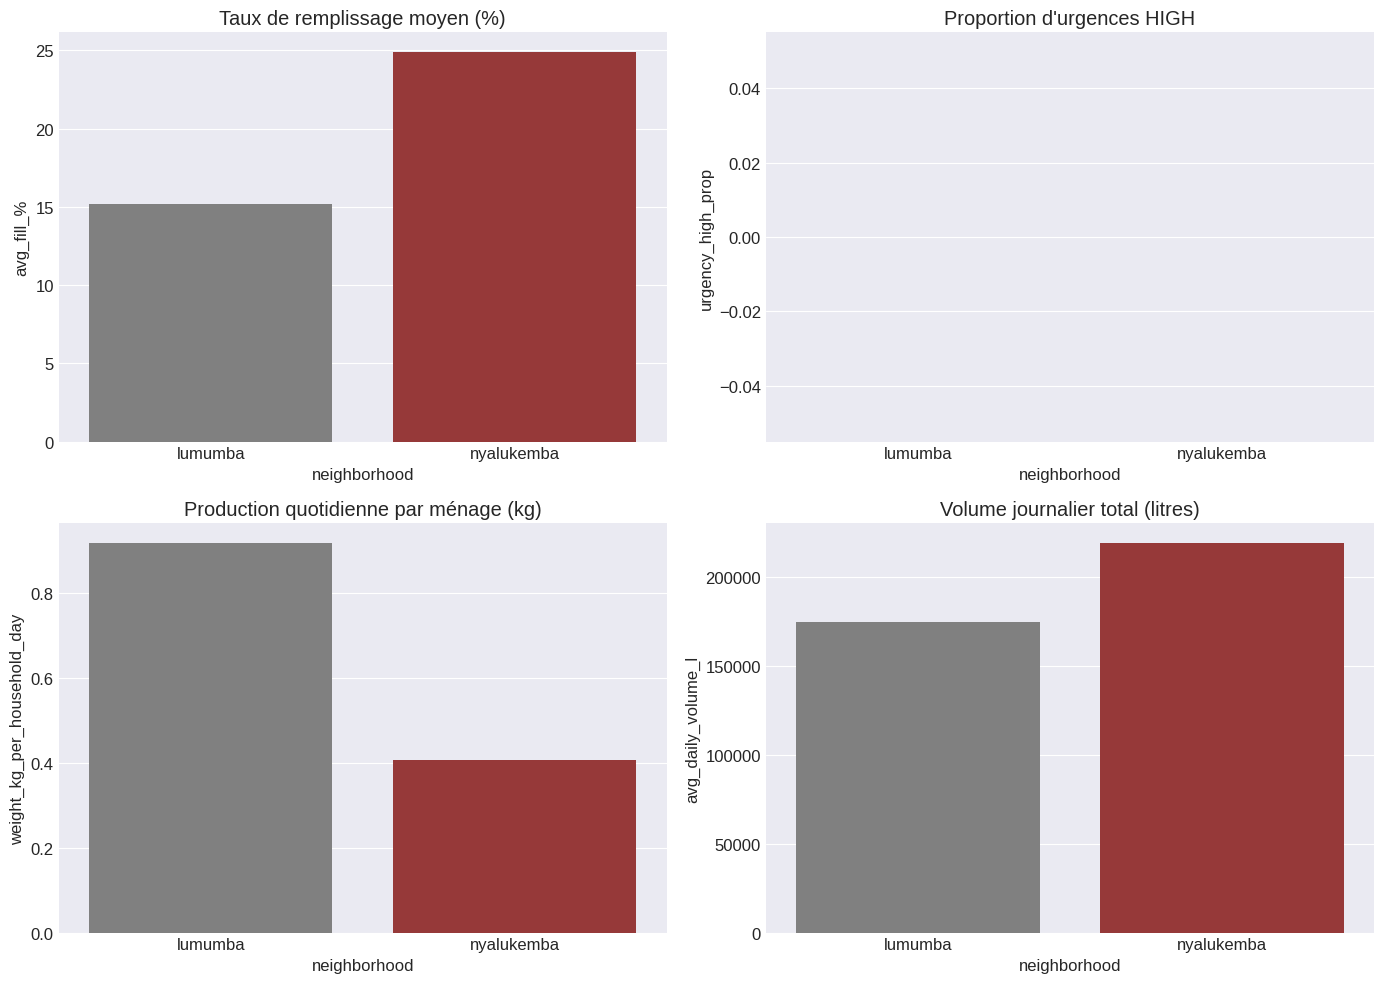


=== Quartiers où la collecte est potentiellement sous-dimensionnée ===
Aucun quartier ne dépasse les seuils définis.


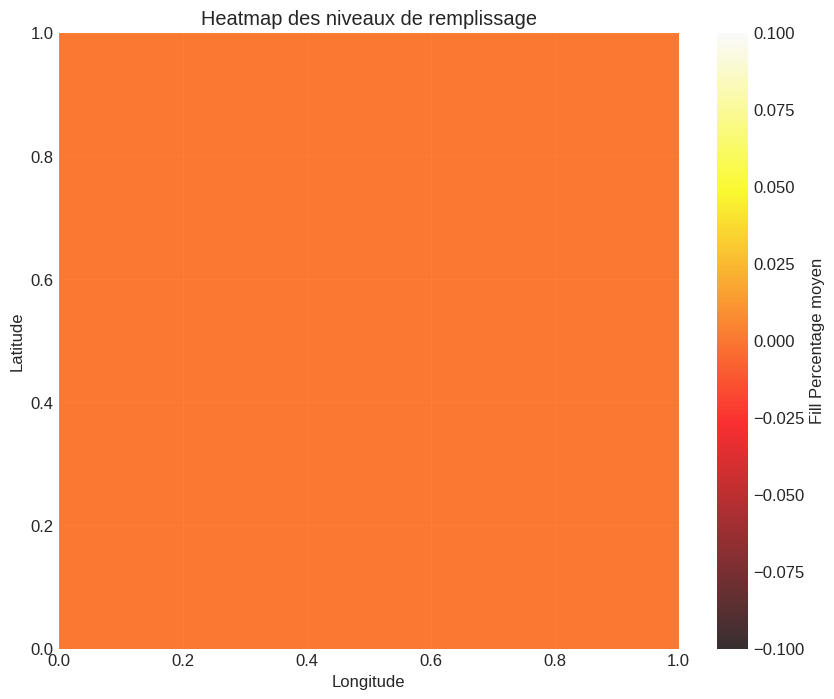

In [66]:
# 14. Comparative waste management analysis across neighborhoods
# -----------------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------------------
# 7.1. Intégration des données démographiques
# -----------------------------------------------------------------------------
# Dictionnaire de correspondance quartier -> commune (municipality)
# Basé sur le texte :
# Ibanda : Nyalukemba, Panzi, Ndendere
# Kadutu : Kajangu, Cimpunda, Kasali, Nkafu, Mosala, Nyakaliba, Nyamugo
# Bagira : Cahi, Nyakavogo, Kasha, Lumumba
# Note : adapter les noms selon vos données réelles
neighborhood_to_municipality = {
    'nyalukemba': 'Ibanda',
    'panzi': 'Ibanda',
    'ndendere': 'Ibanda',
    'cahi': 'Bagira',
    'nyakavogo': 'Bagira',
    'kasha': 'Bagira',
    'lumumba': 'Bagira',
    'kajangu': 'Kadutu',
    'cimpunda': 'Kadutu',
    'kasali': 'Kadutu',
    'nkafu': 'Kadutu',
    'mosala': 'Kadutu',
    'nyakaliba': 'Kadutu',
    'nyamugo': 'Kadutu'
}

# Créer une colonne 'municipality' à partir du quartier (si elle n'existe pas déjà)
if 'municipality' not in df.columns:
    df['municipality'] = df['neighborhood'].map(neighborhood_to_municipality)

# Données démographiques (2026)
demographics = pd.DataFrame({
    'municipality': ['Bagira', 'Kadutu', 'Ibanda'],
    'population_2026': [207602, 549797, 674261],
    'households': [31939, 84584, 103732]
})

# Supprimer les anciennes colonnes pour éviter le conflit lors de la fusion
df = df.drop(columns=['population_2026', 'households'], errors='ignore')

# Fusion avec le dataframe principal (sur la colonne municipality)
df = df.merge(demographics, on='municipality', how='left')

print("=== Données démographiques intégrées ===")
print(df[['neighborhood', 'municipality', 'population_2026', 'households']].drop_duplicates())

# -----------------------------------------------------------------------------
# 7.2. Calcul des indicateurs clés par quartier (neighborhood)
# -----------------------------------------------------------------------------
# Sous-ensemble pour les indicateurs
indicators = df[df['fillPercentage'].notna() | df['collectionUrgency'].notna() | df['wasteWeightKg'].notna()].copy()

# Moyenne du remplissage par quartier
fill_mean = indicators.groupby('neighborhood')['fillPercentage'].mean().round(1).reset_index(name='avg_fill_%')

# Proportion d'urgences HIGH par quartier
if 'collectionUrgency' in indicators.columns:
    urgency_high = indicators[indicators['collectionUrgency'].notna()].copy()
    urgency_high['is_high'] = urgency_high['collectionUrgency'].astype(str).str.upper() == 'HIGH'
    urgency_prop = urgency_high.groupby('neighborhood')['is_high'].mean().reset_index(name='urgency_high_prop')
    urgency_prop['urgency_high_prop'] = urgency_prop['urgency_high_prop'].round(3)
else:
    urgency_prop = pd.DataFrame({'neighborhood': indicators['neighborhood'].unique(), 'urgency_high_prop': np.nan})

# Production moyenne de déchets par jour et par ménage
# Agrégation par quartier et par jour
waste_daily = indicators.groupby(['neighborhood', 'timestamp']).agg(
    total_weight_kg=('wasteWeightKg', 'sum'),
    total_volume_l=('wasteVolumeLiters', 'sum')
).reset_index()
waste_daily['date'] = waste_daily['timestamp'].dt.date
waste_daily = waste_daily.groupby(['neighborhood', 'date']).agg(
    daily_weight_kg=('total_weight_kg', 'sum'),
    daily_volume_l=('total_volume_l', 'sum')
).reset_index()

# Moyenne par jour (toutes dates)
avg_daily = waste_daily.groupby('neighborhood').agg(
    avg_daily_weight_kg=('daily_weight_kg', 'mean'),
    avg_daily_volume_l=('daily_volume_l', 'mean')
).reset_index()

# Récupérer le nombre de ménages par quartier (via la fusion avec municipality)
households_per_neighborhood = indicators[['neighborhood', 'households']].drop_duplicates().dropna(subset=['households'])
avg_daily = avg_daily.merge(households_per_neighborhood, on='neighborhood', how='left')
avg_daily['weight_kg_per_household_day'] = avg_daily['avg_daily_weight_kg'] / avg_daily['households']
avg_daily['volume_l_per_household_day'] = avg_daily['avg_daily_volume_l'] / avg_daily['households']

# Assembler le tableau de bord
dashboard = fill_mean.merge(urgency_prop, on='neighborhood', how='outer')
dashboard = dashboard.merge(avg_daily[['neighborhood', 'avg_daily_weight_kg', 'avg_daily_volume_l',
                                       'weight_kg_per_household_day', 'volume_l_per_household_day']],
                            on='neighborhood', how='left')

print("\n=== Tableau de bord comparatif par quartier ===")
print(dashboard)

# -----------------------------------------------------------------------------
# 7.3. Visualisation du tableau de bord avec couleurs personnalisées
# -----------------------------------------------------------------------------

# Définir un dictionnaire de couleurs pour chaque quartier (exemple avec des couleurs distinctes)
# Vous pouvez personnaliser ces couleurs à votre guise (noms HTML, codes hexadécimaux)
neighborhood_colors = {
    'nyalukemba': 'brown',
    'panzi': 'blue',
    'ndendere': 'green',
    'cahi': 'purple',
    'nyakavogo': 'orange',
    'kasha': 'red',
    'lumumba': 'gray',
    'kajangu': 'magenta',
    'cimpunda': 'olive',
    'kasali': 'cyan',
    'nkafu': 'pink',
    'mosala': 'yellow',
    'nyakaliba': 'teal',
    'nyamugo': 'lime'
}
# Si certains quartiers ne sont pas dans le dictionnaire, une couleur par défaut sera utilisée.

# Préparer l'ordre des quartiers pour les barplots
order = dashboard['neighborhood'].tolist()  # ordre du dataframe
colors = [neighborhood_colors.get(q, 'gray') for q in order]  # récupère la couleur ou 'gray' par défaut

# Barplot comparatif pour chaque indicateur
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(x='neighborhood', y='avg_fill_%', data=dashboard, palette=colors, ax=axes[0,0])
axes[0,0].set_title('Taux de remplissage moyen (%)')

sns.barplot(x='neighborhood', y='urgency_high_prop', data=dashboard, palette=colors, ax=axes[0,1])
axes[0,1].set_title('Proportion d\'urgences HIGH')

sns.barplot(x='neighborhood', y='weight_kg_per_household_day', data=dashboard, palette=colors, ax=axes[1,0])
axes[1,0].set_title('Production quotidienne par ménage (kg)')

sns.barplot(x='neighborhood', y='avg_daily_volume_l', data=dashboard, palette=colors, ax=axes[1,1])
axes[1,1].set_title('Volume journalier total (litres)')

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 7.4. Identification des quartiers sous-dimensionnés
# -----------------------------------------------------------------------------
# Critère : urgence HIGH > 30% ET taux de remplissage > 60% (seuils ajustables)
threshold_urgency = 0.3
threshold_fill = 60
underdimensioned = dashboard[
    (dashboard['urgency_high_prop'] > threshold_urgency) &
    (dashboard['avg_fill_%'] > threshold_fill)
]
print("\n=== Quartiers où la collecte est potentiellement sous-dimensionnée ===")
if not underdimensioned.empty:
    print(underdimensioned[['neighborhood', 'avg_fill_%', 'urgency_high_prop', 'avg_daily_volume_l']])
else:
    print("Aucun quartier ne dépasse les seuils définis.")

# -----------------------------------------------------------------------------
# 7.5. Analyse spatio-temporelle avec couleurs personnalisées
# -----------------------------------------------------------------------------
# Si la colonne 'position' contient des coordonnées, on peut faire une carte de chaleur.
# Sinon, on utilise les quartiers comme unités spatiales pour visualiser l'évolution temporelle.

if 'position' in df.columns and df['position'].notna().any():
    # Extraction approximative des coordonnées (supposées "lat,lon")
    def parse_coord(pos):
        try:
            if isinstance(pos, str):
                parts = pos.split(',')
                if len(parts) == 2:
                    return float(parts[0]), float(parts[1])
        except:
            pass
        return np.nan, np.nan
    coords = df['position'].apply(parse_coord)
    df['lat'] = coords.apply(lambda x: x[0])
    df['lon'] = coords.apply(lambda x: x[1])
    df_spatial = df.dropna(subset=['lat', 'lon']).copy()

    # Carte de chaleur des niveaux de remplissage (moyenne par position)
    # On agrège par grille discrète pour la heatmap (utiliser hist2d)
    plt.figure(figsize=(10,8))
    plt.hist2d(df_spatial['lon'], df_spatial['lat'], weights=df_spatial['fillPercentage'],
               bins=30, cmap='hot', alpha=0.8)
    plt.colorbar(label='Fill Percentage moyen')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Heatmap des niveaux de remplissage')
    plt.show()
else:
    print("Pas de coordonnées disponibles – utilisation de séries temporelles par quartier.")
    # Série temporelle du remplissage moyen par quartier
    daily_fill = df.groupby(['neighborhood', pd.Grouper(key='timestamp', freq='D')])['fillPercentage'].mean().reset_index()
    daily_fill = daily_fill.dropna()
    plt.figure(figsize=(12,6))
    for nb in daily_fill['neighborhood'].unique():
        data = daily_fill[daily_fill['neighborhood'] == nb]
        color = neighborhood_colors.get(nb, 'gray')  # utilise la couleur définie
        plt.plot(data['timestamp'], data['fillPercentage'], marker='o', label=nb, color=color)
    plt.xlabel('Date')
    plt.ylabel('Fill Percentage moyen')
    plt.title('Évolution temporelle du remplissage par quartier')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Heatmap des urgences (nombre d'urgences HIGH par jour et par quartier)
    if 'collectionUrgency' in df.columns:
        urgent = df[df['collectionUrgency'].astype(str).str.upper() == 'HIGH'].copy()
        urgent['date'] = urgent['timestamp'].dt.date
        daily_urgent = urgent.groupby(['neighborhood', 'date']).size().reset_index(name='urgent_count')
        pivot = daily_urgent.pivot(index='date', columns='neighborhood', values='urgent_count').fillna(0)
        plt.figure(figsize=(12,8))
        sns.heatmap(pivot, cmap='Reds', annot=True, fmt='.0f')
        plt.title('Nombre d\'urgences HIGH par jour et quartier')
        plt.ylabel('Date')
        plt.xlabel('Quartier')
        plt.xticks(rotation=45)
        plt.show()


=== Production moyenne par ménage et par jour (par commune) ===
  municipality  weight_kg_per_household_day  volume_l_per_household_day
0       bagira                     0.918329                    5.475252
1       ibanda                     0.406291                    2.114484

=== Extrapolation à la ville de Bukavu (2026) ===
Production journalière estimée : 127,496 kg / 715,193 litres
Production annuelle estimée : 46,535,956 kg (46,536 tonnes) / 261,045,569 litres


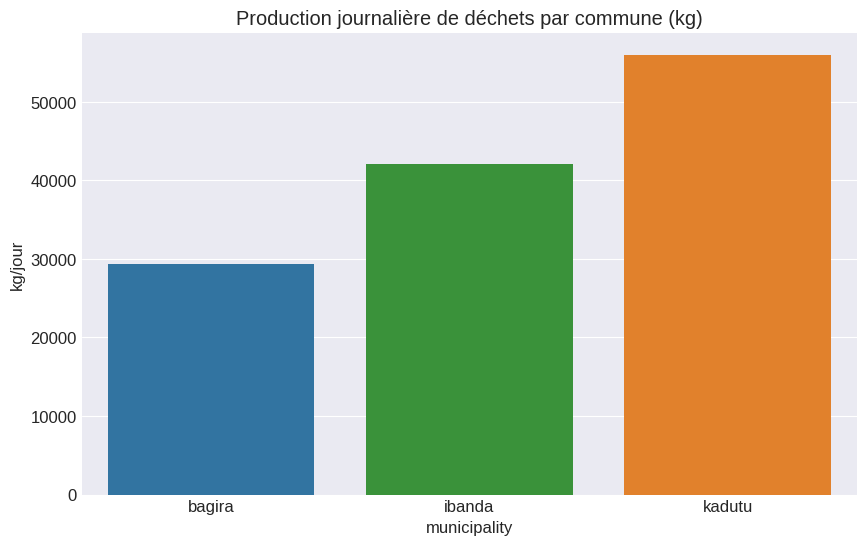


=== Comparaison avec une simple moyenne arithmétique ===
Production journalière estimée (pondérée) : 127,496 kg
Production journalière estimée (moyenne simple) : 899,210 kg
Différence : -771,714 kg


In [85]:
# 15. Weighted extrapolation
# -----------------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Charger les données
if 'df_complete' not in locals():
    # Supposons que df est votre DataFrame chargé depuis les CSV
    df_complete = df[df['wasteWeightKg'].notna()].copy()

# Uniformiser la casse de la colonne municipality (déjà en minuscules d'après l'aperçu)
df_complete['municipality'] = df_complete['municipality'].str.lower()

# 2. Définir le nombre de ménages par commune (source : vos données démographiques)
households_dict = {
    'bagira': 31938,
    'kadutu': 84584,
    'ibanda': 103732
}
# Ajouter la colonne households directement
df_complete['households'] = df_complete['municipality'].map(households_dict)

# Vérifier qu'aucune commune n'est restée sans ménage
if df_complete['households'].isna().any():
    print("⚠️ Des communes n'ont pas de ménages dans le dictionnaire. Voici les communes concernées :")
    print(df_complete[df_complete['households'].isna()]['municipality'].unique())
    # Vous pouvez soit les ignorer (supprimer les lignes) soit attribuer une valeur par défaut
    # Ici on supprime les lignes sans ménage
    df_complete = df_complete.dropna(subset=['households'])

# 3. Créer la colonne date
if 'timestamp' in df_complete.columns:
    df_complete['date'] = pd.to_datetime(df_complete['timestamp']).dt.date
else:
    print("⚠️ Colonne 'timestamp' manquante – utilisation d'une date fictive.")
    df_complete['date'] = pd.Timestamp('2026-01-01').date()

# 4. Agrégation par commune et par jour
daily_by_municipality = df_complete.groupby(['municipality', 'date']).agg(
    total_weight_kg=('wasteWeightKg', 'sum'),
    total_volume_l=('wasteVolumeLiters', 'sum')
).reset_index()

# 5. Production moyenne journalière par commune
avg_daily_by_municipality = daily_by_municipality.groupby('municipality').agg(
    avg_daily_weight_kg=('total_weight_kg', 'mean'),
    avg_daily_volume_l=('total_volume_l', 'mean'),
    count_days=('date', 'count')
).reset_index()

# 6. Ajouter le nombre de ménages (unique par commune)
# On récupère une ligne par commune avec households
households_per_municipality = df_complete[['municipality', 'households']].drop_duplicates()
avg_daily_by_municipality = avg_daily_by_municipality.merge(households_per_municipality, on='municipality', how='left')

# 7. Calcul de la production par ménage et par jour
avg_daily_by_municipality['weight_kg_per_household_day'] = avg_daily_by_municipality['avg_daily_weight_kg'] / avg_daily_by_municipality['households']
avg_daily_by_municipality['volume_l_per_household_day'] = avg_daily_by_municipality['avg_daily_volume_l'] / avg_daily_by_municipality['households']

print("\n=== Production moyenne par ménage et par jour (par commune) ===")
print(avg_daily_by_municipality[['municipality', 'weight_kg_per_household_day', 'volume_l_per_household_day']])

# 8. Extrapolation à la ville entière
# Pour inclure Kadutu même si elle n'a pas de capteurs, on utilise les ménages du dictionnaire
# On crée un DataFrame avec toutes les communes de Bukavu
all_municipalities = pd.DataFrame({'municipality': list(households_dict.keys())})
all_municipalities['households'] = all_municipalities['municipality'].map(households_dict)

extrap = avg_daily_by_municipality.merge(all_municipalities, on='municipality', how='outer')

# Pour les communes sans données mesurées, on utilise la moyenne des communes mesurées
mean_kg = extrap['weight_kg_per_household_day'].mean(skipna=True)
mean_l = extrap['volume_l_per_household_day'].mean(skipna=True)
if pd.isna(mean_kg):
    mean_kg, mean_l = 0.5, 2.0  # valeurs par défaut (si aucune donnée du tout)
    print("⚠️ Aucune donnée mesurée – utilisation de valeurs par défaut.")
extrap['weight_kg_per_household_day'] = extrap['weight_kg_per_household_day'].fillna(mean_kg)
extrap['volume_l_per_household_day'] = extrap['volume_l_per_household_day'].fillna(mean_l)

# S'assurer que la colonne households est bien présente (si elle avait été renommée)
if 'households_x' in extrap.columns:
    extrap['households'] = extrap['households_x'].fillna(extrap['households_y'])
elif 'households_y' in extrap.columns:
    extrap['households'] = extrap['households_y']
elif 'households' not in extrap.columns:
    # Fallback : utiliser le dictionnaire
    extrap['households'] = extrap['municipality'].map(households_dict)

extrap['total_daily_weight_kg_commune'] = extrap['households'] * extrap['weight_kg_per_household_day']
extrap['total_daily_volume_l_commune'] = extrap['households'] * extrap['volume_l_per_household_day']

total_daily_weight_kg_city = extrap['total_daily_weight_kg_commune'].sum()
total_daily_volume_l_city = extrap['total_daily_volume_l_commune'].sum()
total_annual_weight_kg = total_daily_weight_kg_city * 365
total_annual_volume_l = total_daily_volume_l_city * 365

print("\n=== Extrapolation à la ville de Bukavu (2026) ===")
print(f"Production journalière estimée : {total_daily_weight_kg_city:,.0f} kg / {total_daily_volume_l_city:,.0f} litres")
print(f"Production annuelle estimée : {total_annual_weight_kg:,.0f} kg ({total_annual_weight_kg/1000:,.0f} tonnes) / {total_annual_volume_l:,.0f} litres")

# 9. Visualisation avec couleurs personnalisées par commune
# Définition des couleurs pour chaque municipalité
municipality_colors = {
    'bagira': '#1f77b4',   # bleu
    'kadutu': '#ff7f0e',   # orange
    'ibanda': '#2ca02c'    # vert
}
plt.figure(figsize=(10,6))
sns.barplot(x='municipality', y='total_daily_weight_kg_commune', data=extrap, palette=municipality_colors)
plt.title('Production journalière de déchets par commune (kg)')
plt.ylabel('kg/jour')
plt.show()

# 10. Comparaison avec une simple moyenne arithmétique
simple_avg_weight = df_complete['wasteWeightKg'].mean()
simple_avg_volume = df_complete['wasteVolumeLiters'].mean()
total_households = extrap['households'].sum()
simple_extrap_weight = simple_avg_weight * total_households
simple_extrap_volume = simple_avg_volume * total_households
print("\n=== Comparaison avec une simple moyenne arithmétique ===")
print(f"Production journalière estimée (pondérée) : {total_daily_weight_kg_city:,.0f} kg")
print(f"Production journalière estimée (moyenne simple) : {simple_extrap_weight:,.0f} kg")
print(f"Différence : {total_daily_weight_kg_city - simple_extrap_weight:,.0f} kg")

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import plotly
import scipy
import statsmodels
import sklearn
import prophet

libs = {
    "Python": sys.version.split()[0],
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": sns.__version__,
    "plotly": plotly.__version__,
    "scipy": scipy.__version__,
    "statsmodels": statsmodels.__version__,
    "scikit-learn": sklearn.__version__,
    "prophet": prophet.__version__
}

for name, ver in libs.items():
    print(f"{name}: {ver}")

Python: 3.12.13
pandas: 2.2.2
numpy: 2.0.2
matplotlib: 3.10.0
seaborn: 0.13.2
plotly: 5.24.1
scipy: 1.16.3
statsmodels: 0.14.6
scikit-learn: 1.6.1
prophet: 1.3.0
